SHREYAS - PAPER 1
PREDICTION OF HEART DISEASE USING MACHINE LEARNING

All libraries imported successfully!

STEP 1: LOADING HEART DISEASE DATASET

Dataset loaded successfully!

Dataset Shape:
(303, 14)

First 5 rows of dataset:
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       2  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  

STEP 2: CONVERTING TARGET

Target converted into binary classification.

Target Distribution:
target
0    164
1    139
Name: cou

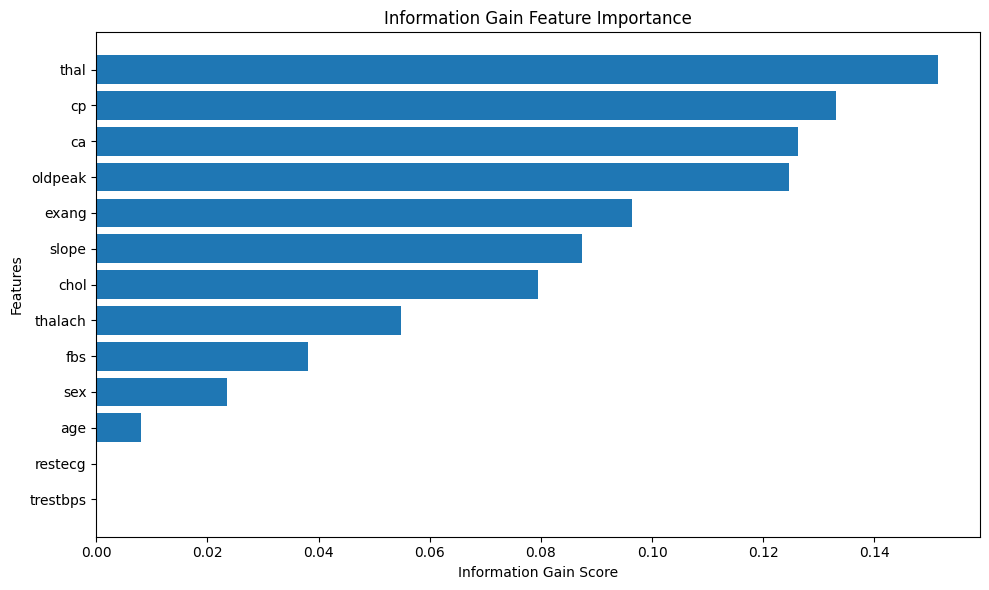


STEP 7: SELECTING IMPORTANT FEATURES

Selected Features:
- thal
- cp
- ca
- oldpeak
- exang
- slope
- chol
- thalach
- fbs
- sex
- age
- restecg

Original Number of Features: 13
Selected Number of Features: 12

STEP 8: TRAIN-TEST SPLIT

Training Samples: 242
Testing Samples: 61

Training Data Shape: (242, 12)
Testing Data Shape: (61, 12)

STEP 9: FEATURE SCALING

Feature Scaling completed successfully!

STEP 10: TRAINING KNN MODEL

KNN Model trained successfully!
KNN Accuracy: 90.16%

STEP 11: TRAINING NAIVE BAYES MODEL

Naive Bayes Model trained successfully!
Naive Bayes Accuracy: 88.52%

STEP 12: TRAINING RANDOM FOREST MODEL

Random Forest Model trained successfully!
Random Forest Accuracy: 85.25%

STEP 13: MODEL PERFORMANCE COMPARISON

MODEL COMPARISON TABLE

        Model  Accuracy  Precision  Recall  F1 Score
          KNN     90.16      82.35  100.00     90.32
  Naive Bayes     88.52      81.82   96.43     88.52
Random Forest     85.25      78.79   92.86     85.25


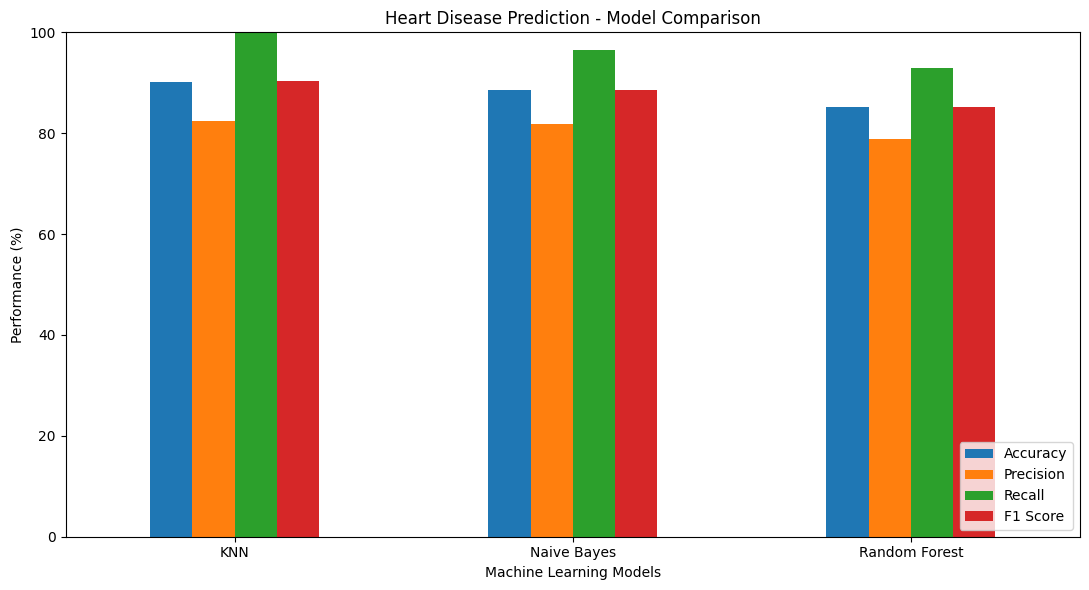


STEP 14: RANDOM FOREST CONFUSION MATRIX

Confusion Matrix:
[[26  7]
 [ 2 26]]


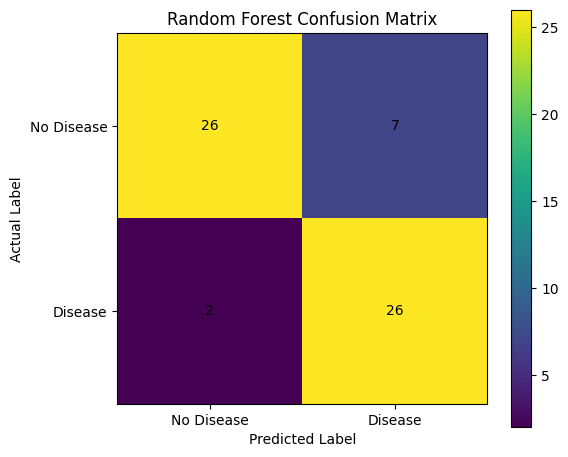


STEP 15: RANDOM FOREST CLASSIFICATION REPORT
                  precision    recall  f1-score   support

No Heart Disease       0.93      0.79      0.85        33
   Heart Disease       0.79      0.93      0.85        28

        accuracy                           0.85        61
       macro avg       0.86      0.86      0.85        61
    weighted avg       0.86      0.85      0.85        61


STEP 16: RANDOM FOREST FEATURE IMPORTANCE

Feature Importance:

Feature  Importance
   thal    0.155017
thalach    0.127438
     cp    0.125899
     ca    0.115024
oldpeak    0.103828
   chol    0.098759
    age    0.097179
  exang    0.053429
  slope    0.049130
    sex    0.040189
restecg    0.023392
    fbs    0.010718


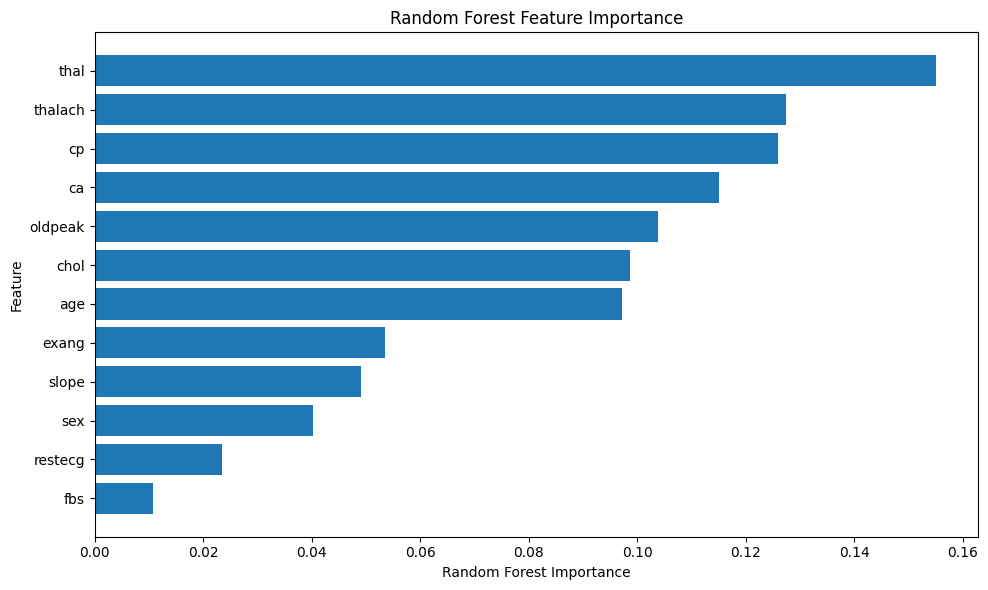


STEP 17: SAMPLE PATIENT PREDICTION

PATIENT PREDICTION RESULT
----------------------------------------
Prediction: HEART DISEASE DETECTED

Probability of No Heart Disease: 30.50%
Probability of Heart Disease: 69.50%


FINAL PAPER 1 RESULT

Paper:
Prediction of Heart Disease Using Machine Learning Algorithms

Authors:
Md. Julker Nayeem Nayeem, Sohel Rana & Md. Rabiul Islam (2022)

Dataset:
UCI Cleveland Heart Disease Dataset

Preprocessing:
Mean-value imputation

Feature Selection:
Information Gain

Models Implemented:
1. K-Nearest Neighbors (KNN)
2. Naive Bayes
3. Random Forest

----------------------------------------------------------------------
OUR EXPERIMENTAL RESULTS
----------------------------------------------------------------------
KNN Accuracy          : 90.16%
Naive Bayes Accuracy  : 88.52%
Random Forest Accuracy: 85.25%

Best Model in This Run:
KNN
Best Accuracy: 90.16%

----------------------------------------------------------------------
PAPER REPORTED RESULT
--------

In [ ]:
# ================================================================
# SHREYAS - PAPER 1
# Prediction of Heart Disease Using Machine Learning Algorithms
# ================================================================


# ================================================================
# 1. IMPORT LIBRARIES
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("=" * 70)
print("SHREYAS - PAPER 1")
print("PREDICTION OF HEART DISEASE USING MACHINE LEARNING")
print("=" * 70)

print("\nAll libraries imported successfully!")


# ================================================================
# 2. LOAD UCI HEART DISEASE DATASET
# ================================================================

print("\n" + "=" * 70)
print("STEP 1: LOADING HEART DISEASE DATASET")
print("=" * 70)

columns = [
    'age',
    'sex',
    'cp',
    'trestbps',
    'chol',
    'fbs',
    'restecg',
    'thalach',
    'exang',
    'oldpeak',
    'slope',
    'ca',
    'thal',
    'target'
]

url = (
    "https://archive.ics.uci.edu/ml/"
    "machine-learning-databases/heart-disease/"
    "processed.cleveland.data"
)

df = pd.read_csv(
    url,
    names=columns,
    na_values='?'
)

print("\nDataset loaded successfully!")

print("\nDataset Shape:")
print(df.shape)

print("\nFirst 5 rows of dataset:")
print(df.head())


# ================================================================
# 3. CONVERT TARGET TO BINARY CLASSIFICATION
# ================================================================

print("\n" + "=" * 70)
print("STEP 2: CONVERTING TARGET")
print("=" * 70)

# Original UCI target:
# 0       = No Heart Disease
# 1,2,3,4 = Heart Disease
#
# Convert into:
# 0 = No Heart Disease
# 1 = Heart Disease

df['target'] = (df['target'] > 0).astype(int)

print("\nTarget converted into binary classification.")

print("\nTarget Distribution:")
print(df['target'].value_counts())

print("\n0 = No Heart Disease")
print("1 = Heart Disease")


# ================================================================
# 4. CHECK MISSING VALUES
# ================================================================

print("\n" + "=" * 70)
print("STEP 3: CHECKING MISSING VALUES")
print("=" * 70)

print("\nMissing values before preprocessing:")

print(df.isnull().sum())


# ================================================================
# 5. MEAN VALUE IMPUTATION
# ================================================================

print("\n" + "=" * 70)
print("STEP 4: MEAN VALUE IMPUTATION")
print("=" * 70)

# Replace missing values with column mean

for column in df.columns:

    if df[column].isnull().sum() > 0:

        mean_value = df[column].mean()

        df[column] = df[column].fillna(mean_value)

        print(
            f"Missing values in '{column}' "
            f"replaced with mean = {mean_value:.2f}"
        )


print("\nMissing values after Mean Imputation:")

print(df.isnull().sum())

print("\nMean-value imputation completed successfully!")


# ================================================================
# 6. SEPARATE FEATURES AND TARGET
# ================================================================

print("\n" + "=" * 70)
print("STEP 5: SEPARATING FEATURES AND TARGET")
print("=" * 70)

X = df.drop(
    'target',
    axis=1
)

y = df['target']

print("\nFeature Matrix Shape:")
print(X.shape)

print("\nTarget Shape:")
print(y.shape)

print("\nAvailable Features:")

for feature in X.columns:
    print("-", feature)


# ================================================================
# 7. INFORMATION GAIN FEATURE SELECTION
# ================================================================

print("\n" + "=" * 70)
print("STEP 6: INFORMATION GAIN FEATURE SELECTION")
print("=" * 70)

information_gain = mutual_info_classif(
    X,
    y,
    random_state=42
)

ig_scores = pd.DataFrame({
    'Feature': X.columns,
    'Information Gain': information_gain
})

ig_scores = ig_scores.sort_values(
    by='Information Gain',
    ascending=False
)

print("\nInformation Gain Scores:")

print(
    ig_scores.to_string(
        index=False
    )
)


# ================================================================
# 8. INFORMATION GAIN GRAPH
# ================================================================

plt.figure(
    figsize=(10, 6)
)

plt.barh(
    ig_scores['Feature'],
    ig_scores['Information Gain']
)

plt.xlabel(
    "Information Gain Score"
)

plt.ylabel(
    "Features"
)

plt.title(
    "Information Gain Feature Importance"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()


# ================================================================
# 9. SELECT IMPORTANT FEATURES
# ================================================================

print("\n" + "=" * 70)
print("STEP 7: SELECTING IMPORTANT FEATURES")
print("=" * 70)

# Select features with Information Gain > 0

selected_features = ig_scores[
    ig_scores['Information Gain'] > 0
]['Feature'].tolist()


# Safety condition:
# If fewer than 5 features are selected,
# select the top 8 features.

if len(selected_features) < 5:

    selected_features = (
        ig_scores
        .head(8)['Feature']
        .tolist()
    )


print("\nSelected Features:")

for feature in selected_features:
    print("-", feature)


X_selected = X[
    selected_features
]


print(
    "\nOriginal Number of Features:",
    X.shape[1]
)

print(
    "Selected Number of Features:",
    X_selected.shape[1]
)


# ================================================================
# 10. TRAIN-TEST SPLIT
# ================================================================

print("\n" + "=" * 70)
print("STEP 8: TRAIN-TEST SPLIT")
print("=" * 70)

X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(
    "\nTraining Samples:",
    X_train.shape[0]
)

print(
    "Testing Samples:",
    X_test.shape[0]
)

print(
    "\nTraining Data Shape:",
    X_train.shape
)

print(
    "Testing Data Shape:",
    X_test.shape
)


# ================================================================
# 11. FEATURE SCALING
# ================================================================

print("\n" + "=" * 70)
print("STEP 9: FEATURE SCALING")
print("=" * 70)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

print(
    "\nFeature Scaling completed successfully!"
)


# ================================================================
# 12. TRAIN KNN MODEL
# ================================================================

print("\n" + "=" * 70)
print("STEP 10: TRAINING KNN MODEL")
print("=" * 70)

knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(
    X_train_scaled,
    y_train
)

knn_predictions = knn.predict(
    X_test_scaled
)

knn_accuracy = accuracy_score(
    y_test,
    knn_predictions
)

print(
    "\nKNN Model trained successfully!"
)

print(
    f"KNN Accuracy: "
    f"{knn_accuracy * 100:.2f}%"
)


# ================================================================
# 13. TRAIN NAIVE BAYES MODEL
# ================================================================

print("\n" + "=" * 70)
print("STEP 11: TRAINING NAIVE BAYES MODEL")
print("=" * 70)

nb = GaussianNB()

nb.fit(
    X_train_scaled,
    y_train
)

nb_predictions = nb.predict(
    X_test_scaled
)

nb_accuracy = accuracy_score(
    y_test,
    nb_predictions
)

print(
    "\nNaive Bayes Model trained successfully!"
)

print(
    f"Naive Bayes Accuracy: "
    f"{nb_accuracy * 100:.2f}%"
)


# ================================================================
# 14. TRAIN RANDOM FOREST MODEL
# ================================================================

print("\n" + "=" * 70)
print("STEP 12: TRAINING RANDOM FOREST MODEL")
print("=" * 70)

random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

random_forest.fit(
    X_train,
    y_train
)

rf_predictions = random_forest.predict(
    X_test
)

rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

print(
    "\nRandom Forest Model trained successfully!"
)

print(
    f"Random Forest Accuracy: "
    f"{rf_accuracy * 100:.2f}%"
)


# ================================================================
# 15. FUNCTION FOR CALCULATING METRICS
# ================================================================

def calculate_metrics(
    actual,
    predicted
):

    accuracy = accuracy_score(
        actual,
        predicted
    )

    precision = precision_score(
        actual,
        predicted,
        zero_division=0
    )

    recall = recall_score(
        actual,
        predicted,
        zero_division=0
    )

    f1 = f1_score(
        actual,
        predicted,
        zero_division=0
    )

    return (
        accuracy,
        precision,
        recall,
        f1
    )


# ================================================================
# 16. CALCULATE METRICS FOR ALL MODELS
# ================================================================

knn_metrics = calculate_metrics(
    y_test,
    knn_predictions
)

nb_metrics = calculate_metrics(
    y_test,
    nb_predictions
)

rf_metrics = calculate_metrics(
    y_test,
    rf_predictions
)


# ================================================================
# 17. CREATE MODEL COMPARISON TABLE
# ================================================================

print("\n" + "=" * 70)
print("STEP 13: MODEL PERFORMANCE COMPARISON")
print("=" * 70)

results = pd.DataFrame({

    'Model': [
        'KNN',
        'Naive Bayes',
        'Random Forest'
    ],

    'Accuracy': [
        knn_metrics[0] * 100,
        nb_metrics[0] * 100,
        rf_metrics[0] * 100
    ],

    'Precision': [
        knn_metrics[1] * 100,
        nb_metrics[1] * 100,
        rf_metrics[1] * 100
    ],

    'Recall': [
        knn_metrics[2] * 100,
        nb_metrics[2] * 100,
        rf_metrics[2] * 100
    ],

    'F1 Score': [
        knn_metrics[3] * 100,
        nb_metrics[3] * 100,
        rf_metrics[3] * 100
    ]
})


results[
    [
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ]
] = results[
    [
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ]
].round(2)


print("\nMODEL COMPARISON TABLE\n")

print(
    results.to_string(
        index=False
    )
)


# ================================================================
# 18. MODEL COMPARISON GRAPH
# ================================================================

results.set_index(
    'Model'
)[
    [
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ]
].plot(
    kind='bar',
    figsize=(11, 6)
)

plt.title(
    "Heart Disease Prediction - Model Comparison"
)

plt.xlabel(
    "Machine Learning Models"
)

plt.ylabel(
    "Performance (%)"
)

plt.ylim(
    0,
    100
)

plt.xticks(
    rotation=0
)

plt.legend(
    loc='lower right'
)

plt.tight_layout()

plt.show()


# ================================================================
# 19. RANDOM FOREST CONFUSION MATRIX
# ================================================================

print("\n" + "=" * 70)
print("STEP 14: RANDOM FOREST CONFUSION MATRIX")
print("=" * 70)

cm = confusion_matrix(
    y_test,
    rf_predictions
)

print("\nConfusion Matrix:")

print(cm)


plt.figure(
    figsize=(6, 5)
)

plt.imshow(
    cm,
    interpolation='nearest'
)

plt.title(
    "Random Forest Confusion Matrix"
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "Actual Label"
)

plt.xticks(
    [0, 1],
    [
        'No Disease',
        'Disease'
    ]
)

plt.yticks(
    [0, 1],
    [
        'No Disease',
        'Disease'
    ]
)

for i in range(2):

    for j in range(2):

        plt.text(
            j,
            i,
            cm[i, j],
            horizontalalignment='center',
            verticalalignment='center'
        )

plt.colorbar()

plt.tight_layout()

plt.show()


# ================================================================
# 20. RANDOM FOREST CLASSIFICATION REPORT
# ================================================================

print("\n" + "=" * 70)
print("STEP 15: RANDOM FOREST CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test,
        rf_predictions,
        target_names=[
            'No Heart Disease',
            'Heart Disease'
        ]
    )
)


# ================================================================
# 21. RANDOM FOREST FEATURE IMPORTANCE
# ================================================================

print("\n" + "=" * 70)
print("STEP 16: RANDOM FOREST FEATURE IMPORTANCE")
print("=" * 70)

feature_importance = pd.DataFrame({

    'Feature':
        X_train.columns,

    'Importance':
        random_forest.feature_importances_

})

feature_importance = (
    feature_importance
    .sort_values(
        by='Importance',
        ascending=False
    )
)

print("\nFeature Importance:\n")

print(
    feature_importance.to_string(
        index=False
    )
)


# ================================================================
# 22. FEATURE IMPORTANCE GRAPH
# ================================================================

plt.figure(
    figsize=(10, 6)
)

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel(
    "Random Forest Importance"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Random Forest Feature Importance"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()


# ================================================================
# 23. SAMPLE NEW PATIENT PREDICTION
# ================================================================

print("\n" + "=" * 70)
print("STEP 17: SAMPLE PATIENT PREDICTION")
print("=" * 70)


# Example patient data
#
# age       = Age
# sex       = 1 Male, 0 Female
# cp        = Chest pain type
# trestbps  = Resting blood pressure
# chol      = Cholesterol
# fbs       = Fasting blood sugar
# restecg   = Resting ECG
# thalach   = Maximum heart rate
# exang     = Exercise-induced angina
# oldpeak   = ST depression
# slope     = Slope
# ca        = Number of major vessels
# thal      = Thalassemia


new_patient = pd.DataFrame([{

    'age': 57,

    'sex': 1,

    'cp': 4,

    'trestbps': 140,

    'chol': 241,

    'fbs': 0,

    'restecg': 0,

    'thalach': 123,

    'exang': 1,

    'oldpeak': 0.2,

    'slope': 2,

    'ca': 0,

    'thal': 7

}])


# Select exactly the same features
# used for model training.

new_patient_selected = new_patient[
    X_train.columns
]


patient_prediction = random_forest.predict(
    new_patient_selected
)[0]


patient_probability = random_forest.predict_proba(
    new_patient_selected
)[0]


print("\nPATIENT PREDICTION RESULT")
print("-" * 40)


if patient_prediction == 1:

    print(
        "Prediction: HEART DISEASE DETECTED"
    )

else:

    print(
        "Prediction: NO HEART DISEASE DETECTED"
    )


print(
    f"\nProbability of No Heart Disease: "
    f"{patient_probability[0] * 100:.2f}%"
)

print(
    f"Probability of Heart Disease: "
    f"{patient_probability[1] * 100:.2f}%"
)


# ================================================================
# 24. FIND BEST MODEL IN OUR EXPERIMENT
# ================================================================

best_model_index = results[
    'Accuracy'
].idxmax()

best_model = results.loc[
    best_model_index
]


# ================================================================
# 25. FINAL RESULT
# ================================================================

print("\n")
print("=" * 70)
print("FINAL PAPER 1 RESULT")
print("=" * 70)

print(
    "\nPaper:"
)

print(
    "Prediction of Heart Disease "
    "Using Machine Learning Algorithms"
)

print(
    "\nAuthors:"
)

print(
    "Md. Julker Nayeem Nayeem, "
    "Sohel Rana & Md. Rabiul Islam (2022)"
)

print("\nDataset:")
print(
    "UCI Cleveland Heart Disease Dataset"
)

print("\nPreprocessing:")
print(
    "Mean-value imputation"
)

print("\nFeature Selection:")
print(
    "Information Gain"
)

print("\nModels Implemented:")
print(
    "1. K-Nearest Neighbors (KNN)"
)

print(
    "2. Naive Bayes"
)

print(
    "3. Random Forest"
)


print("\n" + "-" * 70)

print("OUR EXPERIMENTAL RESULTS")

print("-" * 70)

print(
    f"KNN Accuracy          : "
    f"{knn_accuracy * 100:.2f}%"
)

print(
    f"Naive Bayes Accuracy  : "
    f"{nb_accuracy * 100:.2f}%"
)

print(
    f"Random Forest Accuracy: "
    f"{rf_accuracy * 100:.2f}%"
)


print("\nBest Model in This Run:")

print(
    best_model['Model']
)

print(
    f"Best Accuracy: "
    f"{best_model['Accuracy']:.2f}%"
)


print("\n" + "-" * 70)

print("PAPER REPORTED RESULT")

print("-" * 70)

print(
    "Main/Best Model: Random Forest"
)

print(
    "Reported Accuracy: Approximately 95.63%"
)

print(
    "\nNOTE: Our accuracy may differ from the "
    "paper because of dataset version, "
    "train-test split, preprocessing and "
    "model parameters."
)

print("\n" + "=" * 70)

print(
    "PAPER 1 IMPLEMENTATION COMPLETED SUCCESSFULLY!"
)

print("=" * 70)

SHREYAS - PAPER 2
HEART DISEASE PREDICTION USING MACHINE LEARNING

All libraries imported successfully!

STEP 1: LOADING UCI HEART DISEASE DATASET

Dataset loaded successfully!

Dataset Shape:
(303, 14)

First 5 Rows:
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       2  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  

STEP 2: TARGET CONVERSION

Target converted successfully!

Target Distribution:
target
0    164
1    139
Name: count, dtype: int64

0 = No

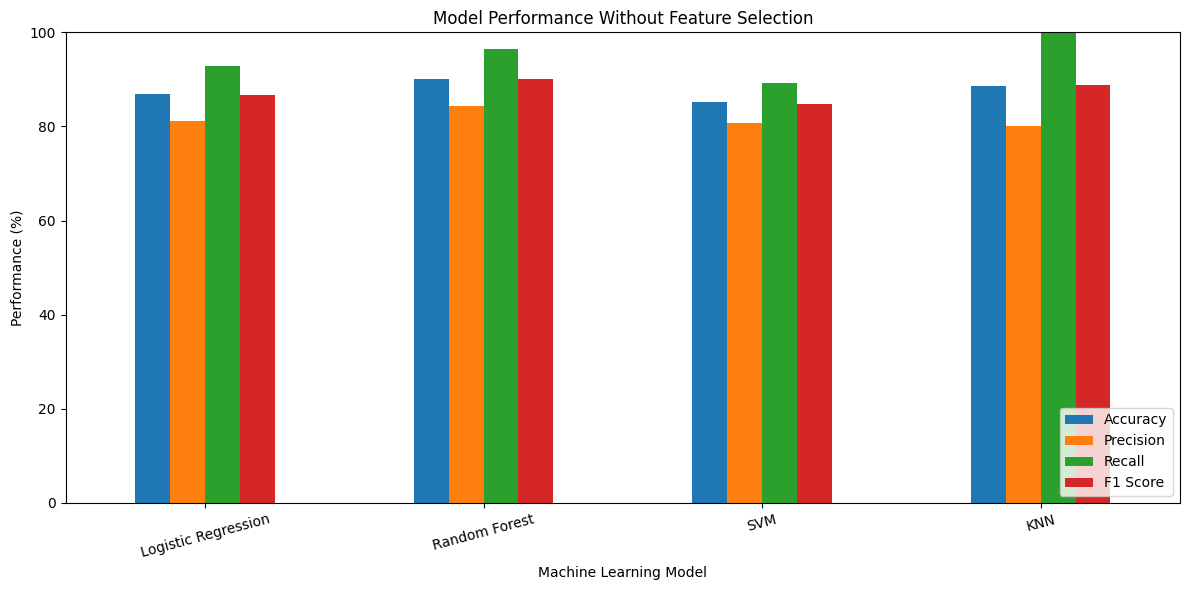


STEP 13: CHI-SQUARE FEATURE SELECTION

Features Selected Using Chi-Square:
- sex
- cp
- restecg
- exang
- oldpeak
- slope
- ca
- thal

Chi-Square Feature Scores:

 Feature  Chi-Square Score
    thal         39.673186
   exang         28.791571
      ca         20.670175
   slope          8.078705
 oldpeak          7.544053
     sex          7.320776
      cp          5.699117
 restecg          3.162825
 thalach          2.010533
     age          0.699249
     fbs          0.435893
trestbps          0.353795
    chol          0.073936


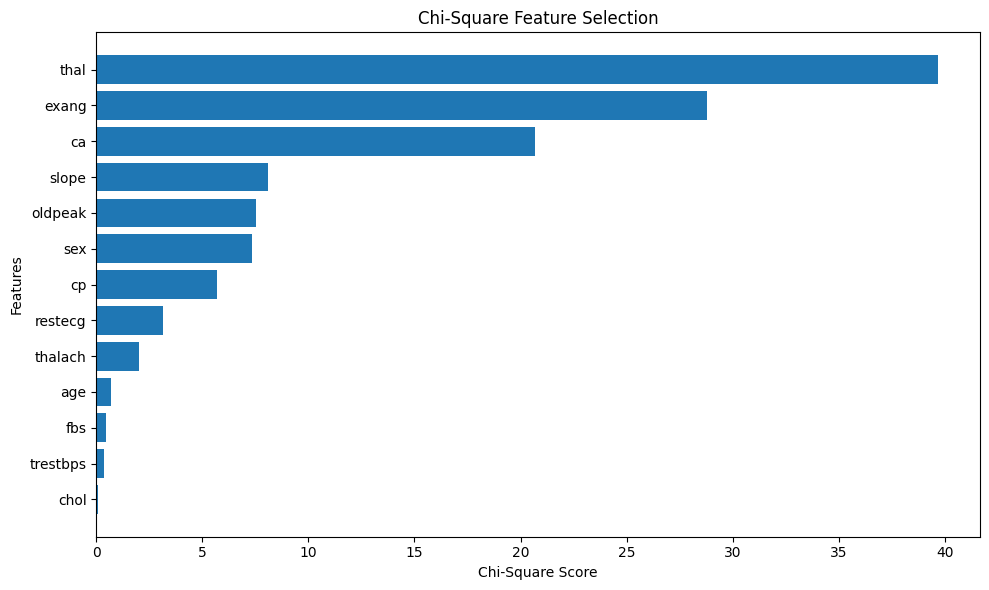


STEP 14: MUTUAL INFORMATION

Mutual Information Scores:

 Feature  Mutual Information
    thal            0.183462
      ca            0.150461
      cp            0.133785
   slope            0.103503
 thalach            0.090736
 oldpeak            0.078996
   exang            0.066024
    chol            0.065494
     sex            0.023632
     fbs            0.020124
 restecg            0.005189
trestbps            0.000000
     age            0.000000


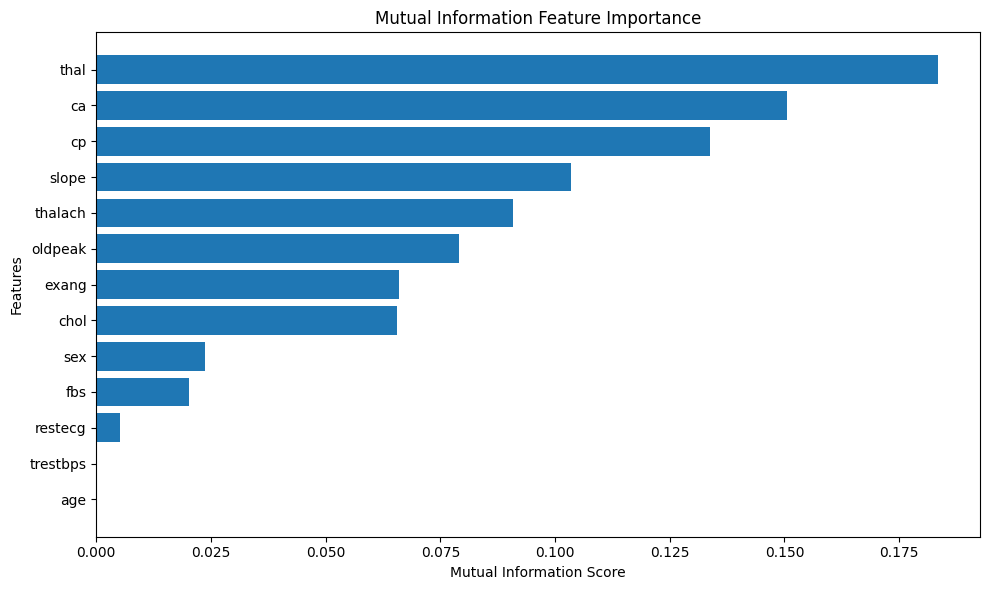


STEP 15: MODELS AFTER CHI-SQUARE FEATURE SELECTION

All models successfully trained after feature selection!

RESULTS AFTER FEATURE SELECTION

              Model  Accuracy  Precision  Recall  F1 Score
Logistic Regression     81.97      77.42   85.71     81.36
      Random Forest     78.69      71.43   89.29     79.37
                SVM     80.33      76.67   82.14     79.31
                KNN     75.41      69.70   82.14     75.41

STEP 16: FEATURE SELECTION COMPARISON

ACCURACY BEFORE VS AFTER FEATURE SELECTION

              Model  Without Feature Selection  With Feature Selection  Difference
Logistic Regression                      86.89                   81.97       -4.92
      Random Forest                      90.16                   78.69      -11.47
                SVM                      85.25                   80.33       -4.92
                KNN                      88.52                   75.41      -13.11


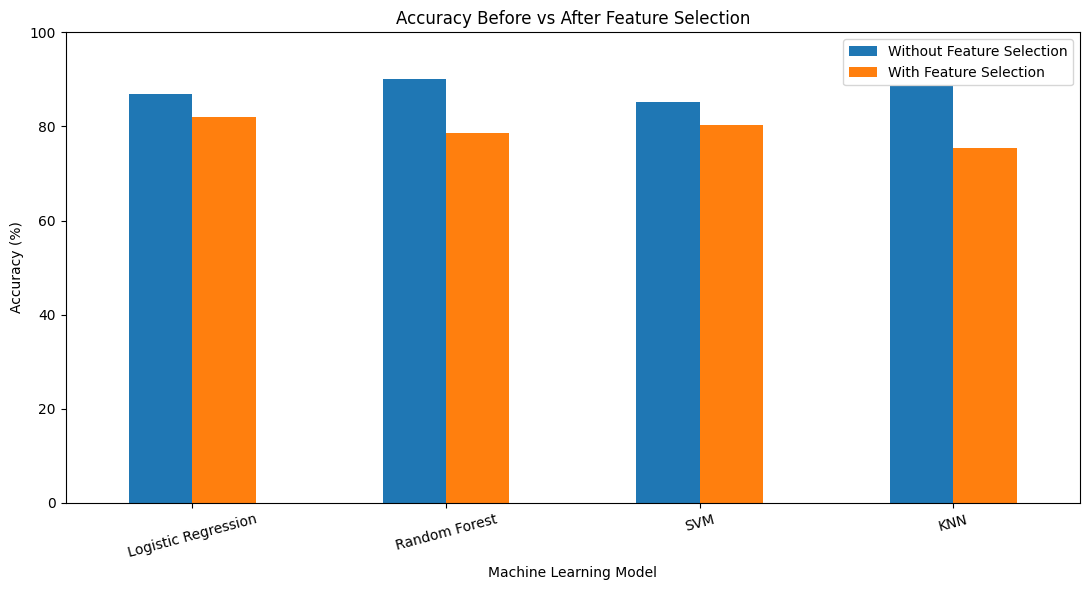


STEP 17: RANDOM FOREST CONFUSION MATRIX

Random Forest Confusion Matrix:
[[28  5]
 [ 1 27]]


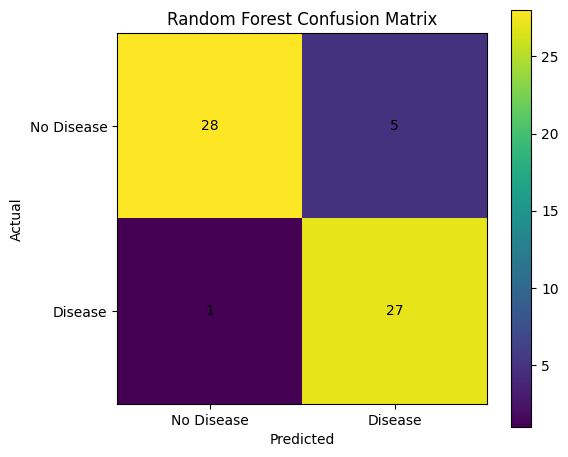


STEP 18: RANDOM FOREST CLASSIFICATION REPORT
                  precision    recall  f1-score   support

No Heart Disease       0.97      0.85      0.90        33
   Heart Disease       0.84      0.96      0.90        28

        accuracy                           0.90        61
       macro avg       0.90      0.91      0.90        61
    weighted avg       0.91      0.90      0.90        61


STEP 19: RANDOM FOREST FEATURE IMPORTANCE

Random Forest Feature Importance:

 Feature  Importance
    thal    0.142406
 thalach    0.122051
      cp    0.115927
      ca    0.105126
     age    0.091680
 oldpeak    0.089759
    chol    0.086475
trestbps    0.080274
   exang    0.053057
   slope    0.042552
     sex    0.038343
 restecg    0.020006
     fbs    0.012343


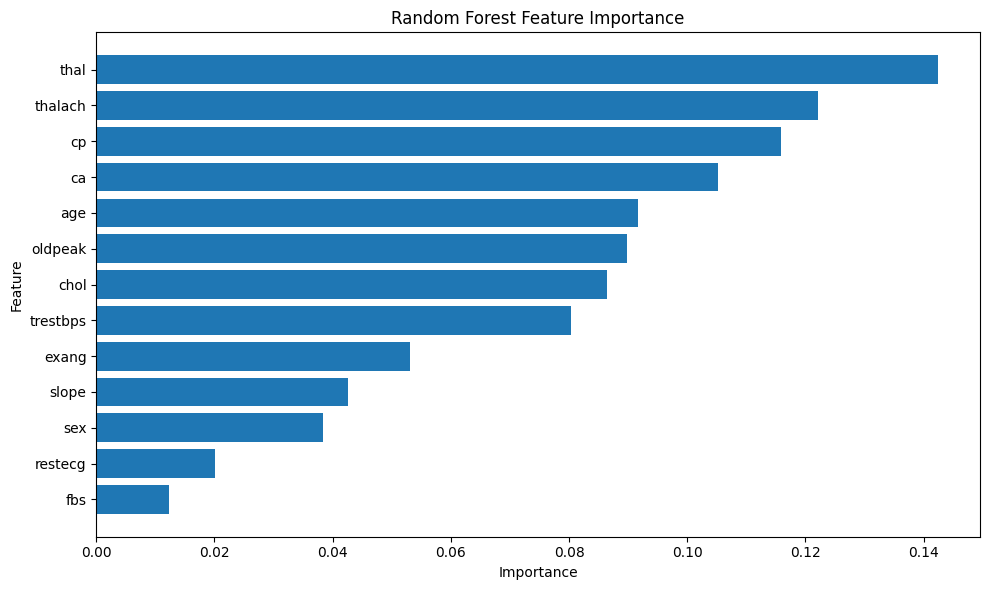


STEP 20: SAMPLE HEART DISEASE PREDICTION

PATIENT RESULT
--------------------------------------------------
Prediction: HEART DISEASE DETECTED

Probability of No Heart Disease: 21.50%
Probability of Heart Disease: 78.50%


SHREYAS - PAPER 2 FINAL RESULTS

Paper:
Predicting Heart Disease Using Machine Learning: An Evaluation of Logistic Regression, Random Forest, SVM, and KNN Models on the UCI Heart Disease Dataset

Authors:
Nurliana Nasution, Mhd Arief Hasan & Feidiansyah Bakri Nasution (2025)

Dataset:
UCI Heart Disease Dataset

Models Implemented:
1. Logistic Regression
2. Random Forest
3. Support Vector Machine (SVM)
4. K-Nearest Neighbors (KNN)

Feature Selection:
1. Chi-Square
2. Mutual Information

---------------------------------------------------------------------------
OUR RESULTS WITHOUT FEATURE SELECTION
---------------------------------------------------------------------------
Logistic Regression : 86.89%
Random Forest       : 90.16%
SVM                 : 85.25%
KNN     

In [ ]:
# =====================================================================
# SHREYAS - PAPER 2
# Predicting Heart Disease Using Machine Learning:
# =====================================================================


# =====================================================================
# 1. IMPORT LIBRARIES
# =====================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from sklearn.feature_selection import (
    SelectKBest,
    chi2,
    mutual_info_classif
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")


print("=" * 75)
print("SHREYAS - PAPER 2")
print("HEART DISEASE PREDICTION USING MACHINE LEARNING")
print("=" * 75)

print("\nAll libraries imported successfully!")


# =====================================================================
# 2. LOAD UCI HEART DISEASE DATASET
# =====================================================================

print("\n" + "=" * 75)
print("STEP 1: LOADING UCI HEART DISEASE DATASET")
print("=" * 75)


columns = [
    'age',
    'sex',
    'cp',
    'trestbps',
    'chol',
    'fbs',
    'restecg',
    'thalach',
    'exang',
    'oldpeak',
    'slope',
    'ca',
    'thal',
    'target'
]


url = (
    "https://archive.ics.uci.edu/ml/"
    "machine-learning-databases/heart-disease/"
    "processed.cleveland.data"
)


df = pd.read_csv(
    url,
    names=columns,
    na_values='?'
)


print("\nDataset loaded successfully!")

print("\nDataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())


# =====================================================================
# 3. CONVERT TARGET INTO BINARY CLASSIFICATION
# =====================================================================

print("\n" + "=" * 75)
print("STEP 2: TARGET CONVERSION")
print("=" * 75)


# Original:
# 0       = No Heart Disease
# 1,2,3,4 = Heart Disease
#
# Convert to:
# 0 = No Heart Disease
# 1 = Heart Disease


df['target'] = (
    df['target'] > 0
).astype(int)


print("\nTarget converted successfully!")

print("\nTarget Distribution:")
print(df['target'].value_counts())

print("\n0 = No Heart Disease")
print("1 = Heart Disease")


# =====================================================================
# 4. CHECK MISSING VALUES
# =====================================================================

print("\n" + "=" * 75)
print("STEP 3: CHECKING MISSING VALUES")
print("=" * 75)


print("\nMissing Values:")

print(
    df.isnull().sum()
)


# =====================================================================
# 5. HANDLE MISSING VALUES
# =====================================================================

print("\n" + "=" * 75)
print("STEP 4: HANDLING MISSING VALUES")
print("=" * 75)


for column in df.columns:

    if df[column].isnull().sum() > 0:

        median_value = df[column].median()

        df[column] = df[column].fillna(
            median_value
        )

        print(
            f"{column}: Missing values replaced "
            f"with median = {median_value:.2f}"
        )


print("\nMissing Values After Preprocessing:")

print(
    df.isnull().sum()
)


# =====================================================================
# 6. SEPARATE INPUT AND OUTPUT
# =====================================================================

print("\n" + "=" * 75)
print("STEP 5: SEPARATING FEATURES AND TARGET")
print("=" * 75)


X = df.drop(
    'target',
    axis=1
)

y = df['target']


print("\nFeature Matrix Shape:")
print(X.shape)

print("\nTarget Shape:")
print(y.shape)

print("\nFeatures:")

for feature in X.columns:

    print("-", feature)


# =====================================================================
# 7. TRAIN / TEST SPLIT
# =====================================================================

print("\n" + "=" * 75)
print("STEP 6: TRAIN-TEST SPLIT")
print("=" * 75)


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print(
    "\nTraining Samples:",
    X_train.shape[0]
)

print(
    "Testing Samples:",
    X_test.shape[0]
)


# =====================================================================
# 8. FEATURE SCALING
# =====================================================================

print("\n" + "=" * 75)
print("STEP 7: FEATURE SCALING")
print("=" * 75)


scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(
    X_train
)


X_test_scaled = scaler.transform(
    X_test
)


print("\nFeature Scaling Completed!")


# =====================================================================
# FUNCTION TO CALCULATE PERFORMANCE
# =====================================================================

def calculate_metrics(
    y_true,
    y_pred
):

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    return (
        accuracy,
        precision,
        recall,
        f1
    )


# =====================================================================
# 9. LOGISTIC REGRESSION
# =====================================================================

print("\n" + "=" * 75)
print("STEP 8: LOGISTIC REGRESSION")
print("=" * 75)


lr_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)


lr_model.fit(
    X_train_scaled,
    y_train
)


lr_prediction = lr_model.predict(
    X_test_scaled
)


lr_metrics = calculate_metrics(
    y_test,
    lr_prediction
)


print("\nLogistic Regression trained successfully!")

print(
    f"Accuracy: "
    f"{lr_metrics[0] * 100:.2f}%"
)


# =====================================================================
# 10. RANDOM FOREST
# =====================================================================

print("\n" + "=" * 75)
print("STEP 9: RANDOM FOREST")
print("=" * 75)


rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)


rf_model.fit(
    X_train,
    y_train
)


rf_prediction = rf_model.predict(
    X_test
)


rf_metrics = calculate_metrics(
    y_test,
    rf_prediction
)


print("\nRandom Forest trained successfully!")

print(
    f"Accuracy: "
    f"{rf_metrics[0] * 100:.2f}%"
)


# =====================================================================
# 11. SUPPORT VECTOR MACHINE (SVM)
# =====================================================================

print("\n" + "=" * 75)
print("STEP 10: SUPPORT VECTOR MACHINE (SVM)")
print("=" * 75)


svm_model = SVC(
    kernel='rbf',
    probability=True,
    random_state=42
)


svm_model.fit(
    X_train_scaled,
    y_train
)


svm_prediction = svm_model.predict(
    X_test_scaled
)


svm_metrics = calculate_metrics(
    y_test,
    svm_prediction
)


print("\nSVM trained successfully!")

print(
    f"Accuracy: "
    f"{svm_metrics[0] * 100:.2f}%"
)


# =====================================================================
# 12. K-NEAREST NEIGHBORS
# =====================================================================

print("\n" + "=" * 75)
print("STEP 11: K-NEAREST NEIGHBORS (KNN)")
print("=" * 75)


knn_model = KNeighborsClassifier(
    n_neighbors=5
)


knn_model.fit(
    X_train_scaled,
    y_train
)


knn_prediction = knn_model.predict(
    X_test_scaled
)


knn_metrics = calculate_metrics(
    y_test,
    knn_prediction
)


print("\nKNN trained successfully!")

print(
    f"Accuracy: "
    f"{knn_metrics[0] * 100:.2f}%"
)


# =====================================================================
# 13. MODEL COMPARISON WITHOUT FEATURE SELECTION
# =====================================================================

print("\n" + "=" * 75)
print("STEP 12: MODEL COMPARISON - WITHOUT FEATURE SELECTION")
print("=" * 75)


results_without_fs = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'Random Forest',
        'SVM',
        'KNN'
    ],

    'Accuracy': [
        lr_metrics[0] * 100,
        rf_metrics[0] * 100,
        svm_metrics[0] * 100,
        knn_metrics[0] * 100
    ],

    'Precision': [
        lr_metrics[1] * 100,
        rf_metrics[1] * 100,
        svm_metrics[1] * 100,
        knn_metrics[1] * 100
    ],

    'Recall': [
        lr_metrics[2] * 100,
        rf_metrics[2] * 100,
        svm_metrics[2] * 100,
        knn_metrics[2] * 100
    ],

    'F1 Score': [
        lr_metrics[3] * 100,
        rf_metrics[3] * 100,
        svm_metrics[3] * 100,
        knn_metrics[3] * 100
    ]
})


results_without_fs[
    [
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ]
] = results_without_fs[
    [
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ]
].round(2)


print(
    "\nRESULTS WITHOUT FEATURE SELECTION\n"
)


print(
    results_without_fs.to_string(
        index=False
    )
)


# =====================================================================
# 14. GRAPH - MODELS WITHOUT FEATURE SELECTION
# =====================================================================

results_without_fs.set_index(
    'Model'
)[
    [
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ]
].plot(
    kind='bar',
    figsize=(12, 6)
)


plt.title(
    "Model Performance Without Feature Selection"
)

plt.ylabel(
    "Performance (%)"
)

plt.xlabel(
    "Machine Learning Model"
)

plt.ylim(
    0,
    100
)

plt.xticks(
    rotation=15
)

plt.legend(
    loc='lower right'
)

plt.tight_layout()

plt.show()


# =====================================================================
# 15. CHI-SQUARE FEATURE SELECTION
# =====================================================================

print("\n" + "=" * 75)
print("STEP 13: CHI-SQUARE FEATURE SELECTION")
print("=" * 75)


# Chi-square requires non-negative data.
# Therefore MinMaxScaler is used.


minmax_scaler = MinMaxScaler()


X_train_nonnegative = minmax_scaler.fit_transform(
    X_train
)


X_test_nonnegative = minmax_scaler.transform(
    X_test
)


# Select top 8 features

chi_selector = SelectKBest(
    score_func=chi2,
    k=8
)


X_train_chi = chi_selector.fit_transform(
    X_train_nonnegative,
    y_train
)


X_test_chi = chi_selector.transform(
    X_test_nonnegative
)


chi_selected_features = X.columns[
    chi_selector.get_support()
].tolist()


print(
    "\nFeatures Selected Using Chi-Square:"
)


for feature in chi_selected_features:

    print("-", feature)


# =====================================================================
# 16. CHI-SQUARE SCORES
# =====================================================================

chi_scores = pd.DataFrame({

    'Feature':
        X.columns,

    'Chi-Square Score':
        chi_selector.scores_

})


chi_scores = chi_scores.sort_values(
    by='Chi-Square Score',
    ascending=False
)


print("\nChi-Square Feature Scores:\n")


print(
    chi_scores.to_string(
        index=False
    )
)


# =====================================================================
# 17. CHI-SQUARE GRAPH
# =====================================================================

plt.figure(
    figsize=(10, 6)
)


plt.barh(
    chi_scores['Feature'],
    chi_scores['Chi-Square Score']
)


plt.title(
    "Chi-Square Feature Selection"
)

plt.xlabel(
    "Chi-Square Score"
)

plt.ylabel(
    "Features"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()


# =====================================================================
# 18. MUTUAL INFORMATION
# =====================================================================

print("\n" + "=" * 75)
print("STEP 14: MUTUAL INFORMATION")
print("=" * 75)


mi_scores_values = mutual_info_classif(
    X_train,
    y_train,
    random_state=42
)


mi_scores = pd.DataFrame({

    'Feature':
        X.columns,

    'Mutual Information':
        mi_scores_values

})


mi_scores = mi_scores.sort_values(
    by='Mutual Information',
    ascending=False
)


print(
    "\nMutual Information Scores:\n"
)


print(
    mi_scores.to_string(
        index=False
    )
)


# =====================================================================
# 19. MUTUAL INFORMATION GRAPH
# =====================================================================

plt.figure(
    figsize=(10, 6)
)


plt.barh(
    mi_scores['Feature'],
    mi_scores['Mutual Information']
)


plt.title(
    "Mutual Information Feature Importance"
)

plt.xlabel(
    "Mutual Information Score"
)

plt.ylabel(
    "Features"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()


# =====================================================================
# 20. TRAIN MODELS AFTER FEATURE SELECTION
# =====================================================================

print("\n" + "=" * 75)
print("STEP 15: MODELS AFTER CHI-SQUARE FEATURE SELECTION")
print("=" * 75)


# Logistic Regression

lr_fs = LogisticRegression(
    max_iter=2000,
    random_state=42
)

lr_fs.fit(
    X_train_chi,
    y_train
)

lr_fs_prediction = lr_fs.predict(
    X_test_chi
)

lr_fs_metrics = calculate_metrics(
    y_test,
    lr_fs_prediction
)


# Random Forest

rf_fs = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_fs.fit(
    X_train_chi,
    y_train
)

rf_fs_prediction = rf_fs.predict(
    X_test_chi
)

rf_fs_metrics = calculate_metrics(
    y_test,
    rf_fs_prediction
)


# SVM

svm_fs = SVC(
    kernel='rbf',
    probability=True,
    random_state=42
)

svm_fs.fit(
    X_train_chi,
    y_train
)

svm_fs_prediction = svm_fs.predict(
    X_test_chi
)

svm_fs_metrics = calculate_metrics(
    y_test,
    svm_fs_prediction
)


# KNN

knn_fs = KNeighborsClassifier(
    n_neighbors=5
)

knn_fs.fit(
    X_train_chi,
    y_train
)

knn_fs_prediction = knn_fs.predict(
    X_test_chi
)

knn_fs_metrics = calculate_metrics(
    y_test,
    knn_fs_prediction
)


print(
    "\nAll models successfully trained "
    "after feature selection!"
)


# =====================================================================
# 21. RESULTS AFTER FEATURE SELECTION
# =====================================================================

results_with_fs = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'Random Forest',
        'SVM',
        'KNN'
    ],

    'Accuracy': [
        lr_fs_metrics[0] * 100,
        rf_fs_metrics[0] * 100,
        svm_fs_metrics[0] * 100,
        knn_fs_metrics[0] * 100
    ],

    'Precision': [
        lr_fs_metrics[1] * 100,
        rf_fs_metrics[1] * 100,
        svm_fs_metrics[1] * 100,
        knn_fs_metrics[1] * 100
    ],

    'Recall': [
        lr_fs_metrics[2] * 100,
        rf_fs_metrics[2] * 100,
        svm_fs_metrics[2] * 100,
        knn_fs_metrics[2] * 100
    ],

    'F1 Score': [
        lr_fs_metrics[3] * 100,
        rf_fs_metrics[3] * 100,
        svm_fs_metrics[3] * 100,
        knn_fs_metrics[3] * 100
    ]

})


results_with_fs[
    [
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ]
] = results_with_fs[
    [
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ]
].round(2)


print(
    "\nRESULTS AFTER FEATURE SELECTION\n"
)


print(
    results_with_fs.to_string(
        index=False
    )
)


# =====================================================================
# 22. COMPARE ACCURACY BEFORE AND AFTER FEATURE SELECTION
# =====================================================================

print("\n" + "=" * 75)
print("STEP 16: FEATURE SELECTION COMPARISON")
print("=" * 75)


comparison = pd.DataFrame({

    'Model':
        results_without_fs['Model'],

    'Without Feature Selection':
        results_without_fs['Accuracy'],

    'With Feature Selection':
        results_with_fs['Accuracy']

})


comparison[
    'Difference'
] = (

    comparison[
        'With Feature Selection'
    ]

    -

    comparison[
        'Without Feature Selection'
    ]
)


comparison[
    'Difference'
] = comparison[
    'Difference'
].round(2)


print(
    "\nACCURACY BEFORE VS AFTER FEATURE SELECTION\n"
)


print(
    comparison.to_string(
        index=False
    )
)


# =====================================================================
# 23. FEATURE SELECTION COMPARISON GRAPH
# =====================================================================

comparison.set_index(
    'Model'
)[
    [
        'Without Feature Selection',
        'With Feature Selection'
    ]
].plot(
    kind='bar',
    figsize=(11, 6)
)


plt.title(
    "Accuracy Before vs After Feature Selection"
)

plt.ylabel(
    "Accuracy (%)"
)

plt.xlabel(
    "Machine Learning Model"
)

plt.ylim(
    0,
    100
)

plt.xticks(
    rotation=15
)

plt.tight_layout()

plt.show()


# =====================================================================
# 24. RANDOM FOREST CONFUSION MATRIX
# =====================================================================

print("\n" + "=" * 75)
print("STEP 17: RANDOM FOREST CONFUSION MATRIX")
print("=" * 75)


rf_cm = confusion_matrix(
    y_test,
    rf_prediction
)


print("\nRandom Forest Confusion Matrix:")

print(rf_cm)


plt.figure(
    figsize=(6, 5)
)


plt.imshow(
    rf_cm,
    interpolation='nearest'
)


plt.title(
    "Random Forest Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)


plt.xticks(
    [0, 1],
    [
        'No Disease',
        'Disease'
    ]
)


plt.yticks(
    [0, 1],
    [
        'No Disease',
        'Disease'
    ]
)


for i in range(2):

    for j in range(2):

        plt.text(
            j,
            i,
            rf_cm[i, j],
            horizontalalignment='center',
            verticalalignment='center'
        )


plt.colorbar()

plt.tight_layout()

plt.show()


# =====================================================================
# 25. RANDOM FOREST CLASSIFICATION REPORT
# =====================================================================

print("\n" + "=" * 75)
print("STEP 18: RANDOM FOREST CLASSIFICATION REPORT")
print("=" * 75)


print(
    classification_report(
        y_test,
        rf_prediction,
        target_names=[
            'No Heart Disease',
            'Heart Disease'
        ]
    )
)


# =====================================================================
# 26. RANDOM FOREST FEATURE IMPORTANCE
# =====================================================================

print("\n" + "=" * 75)
print("STEP 19: RANDOM FOREST FEATURE IMPORTANCE")
print("=" * 75)


rf_importance = pd.DataFrame({

    'Feature':
        X.columns,

    'Importance':
        rf_model.feature_importances_

})


rf_importance = rf_importance.sort_values(
    by='Importance',
    ascending=False
)


print(
    "\nRandom Forest Feature Importance:\n"
)


print(
    rf_importance.to_string(
        index=False
    )
)


# =====================================================================
# 27. RANDOM FOREST FEATURE IMPORTANCE GRAPH
# =====================================================================

plt.figure(
    figsize=(10, 6)
)


plt.barh(
    rf_importance['Feature'],
    rf_importance['Importance']
)


plt.title(
    "Random Forest Feature Importance"
)

plt.xlabel(
    "Importance"
)

plt.ylabel(
    "Feature"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()


# =====================================================================
# 28. SAMPLE PATIENT PREDICTION
# =====================================================================

print("\n" + "=" * 75)
print("STEP 20: SAMPLE HEART DISEASE PREDICTION")
print("=" * 75)


new_patient = pd.DataFrame([{

    'age': 57,

    'sex': 1,

    'cp': 4,

    'trestbps': 140,

    'chol': 241,

    'fbs': 0,

    'restecg': 0,

    'thalach': 123,

    'exang': 1,

    'oldpeak': 0.2,

    'slope': 2,

    'ca': 0,

    'thal': 7

}])


# Random Forest does not require scaling

prediction = rf_model.predict(
    new_patient
)[0]


probability = rf_model.predict_proba(
    new_patient
)[0]


print("\nPATIENT RESULT")
print("-" * 50)


if prediction == 1:

    print(
        "Prediction: HEART DISEASE DETECTED"
    )

else:

    print(
        "Prediction: NO HEART DISEASE DETECTED"
    )


print(
    f"\nProbability of No Heart Disease: "
    f"{probability[0] * 100:.2f}%"
)


print(
    f"Probability of Heart Disease: "
    f"{probability[1] * 100:.2f}%"
)


# =====================================================================
# 29. FIND BEST MODEL
# =====================================================================

best_index = results_without_fs[
    'Accuracy'
].idxmax()


best_model = results_without_fs.loc[
    best_index
]


# =====================================================================
# 30. FINAL PAPER SUMMARY
# =====================================================================

print("\n")
print("=" * 75)
print("SHREYAS - PAPER 2 FINAL RESULTS")
print("=" * 75)


print(
    "\nPaper:"
)

print(
    "Predicting Heart Disease Using Machine Learning: "
    "An Evaluation of Logistic Regression, Random Forest, "
    "SVM, and KNN Models on the UCI Heart Disease Dataset"
)


print(
    "\nAuthors:"
)

print(
    "Nurliana Nasution, Mhd Arief Hasan & "
    "Feidiansyah Bakri Nasution (2025)"
)


print(
    "\nDataset:"
)

print(
    "UCI Heart Disease Dataset"
)


print(
    "\nModels Implemented:"
)

print(
    "1. Logistic Regression"
)

print(
    "2. Random Forest"
)

print(
    "3. Support Vector Machine (SVM)"
)

print(
    "4. K-Nearest Neighbors (KNN)"
)


print(
    "\nFeature Selection:"
)

print(
    "1. Chi-Square"
)

print(
    "2. Mutual Information"
)


print("\n" + "-" * 75)
print("OUR RESULTS WITHOUT FEATURE SELECTION")
print("-" * 75)


print(
    f"Logistic Regression : "
    f"{lr_metrics[0] * 100:.2f}%"
)

print(
    f"Random Forest       : "
    f"{rf_metrics[0] * 100:.2f}%"
)

print(
    f"SVM                 : "
    f"{svm_metrics[0] * 100:.2f}%"
)

print(
    f"KNN                 : "
    f"{knn_metrics[0] * 100:.2f}%"
)


print("\nBest Model in Our Run:")

print(
    best_model['Model']
)


print(
    f"Best Accuracy: "
    f"{best_model['Accuracy']:.2f}%"
)


print("\n" + "-" * 75)
print("PAPER REPORTED RESULT")
print("-" * 75)


print(
    "Paper Main/Best Model: Random Forest"
)

print(
    "Reported Random Forest Accuracy "
    "without Feature Selection: ~89.7%"
)


print(
    "\nThe paper reports that feature selection "
    "did not substantially improve model performance."
)


print(
    "\nNOTE: Our accuracy may differ from the paper "
    "because of differences in dataset version, "
    "train-test split, preprocessing and "
    "hyperparameters."
)


print("\n" + "=" * 75)

print(
    "PAPER 2 IMPLEMENTATION COMPLETED SUCCESSFULLY!"
)

print("=" * 75)

SHREYAS - PAPER 3
HEART DISEASE PREDICTION USING ML + DEEP LEARNING

All libraries imported successfully!

STEP 1: LOADING UCI HEART DISEASE DATASET

Dataset loaded successfully!

Dataset Shape:
(303, 14)

First 5 Rows:
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       2  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  

STEP 2: TARGET CONVERSION

Target converted successfully!

Target Distribution:
target
0    164
1    139
Name: count, dtype: int64

STEP

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,521 (13.75 KB)

 Trainable params: 3,521 (13.75 KB)

 Non-trainable params: 0 (0.00 B)


STEP 14: TRAINING DEEP LEARNING MODEL

Deep Learning Model Training Completed!
Epochs Used: 25

Deep Learning Accuracy: 79.31%


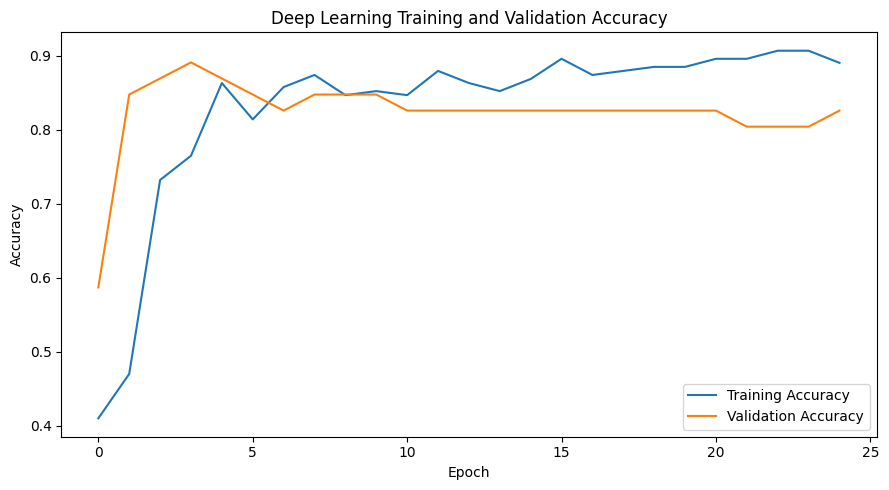

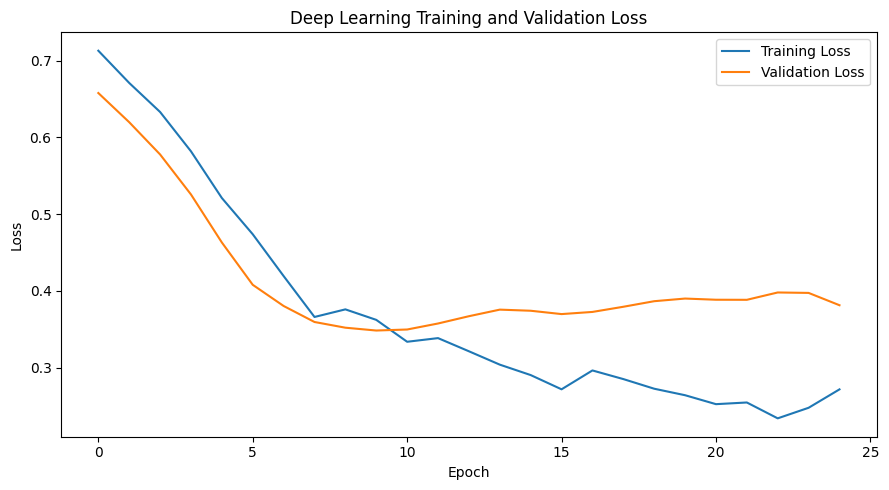


STEP 15: MACHINE LEARNING VS DEEP LEARNING

MODEL COMPARISON

              Model  Accuracy  Precision  Recall  F1 Score
Logistic Regression     82.76      86.36   73.08     79.17
                KNN     77.59      76.00   73.08     74.51
                SVM     81.03      82.61   73.08     77.55
      Random Forest     77.59      76.00   73.08     74.51
      Deep Learning     79.31      85.00   65.38     73.91


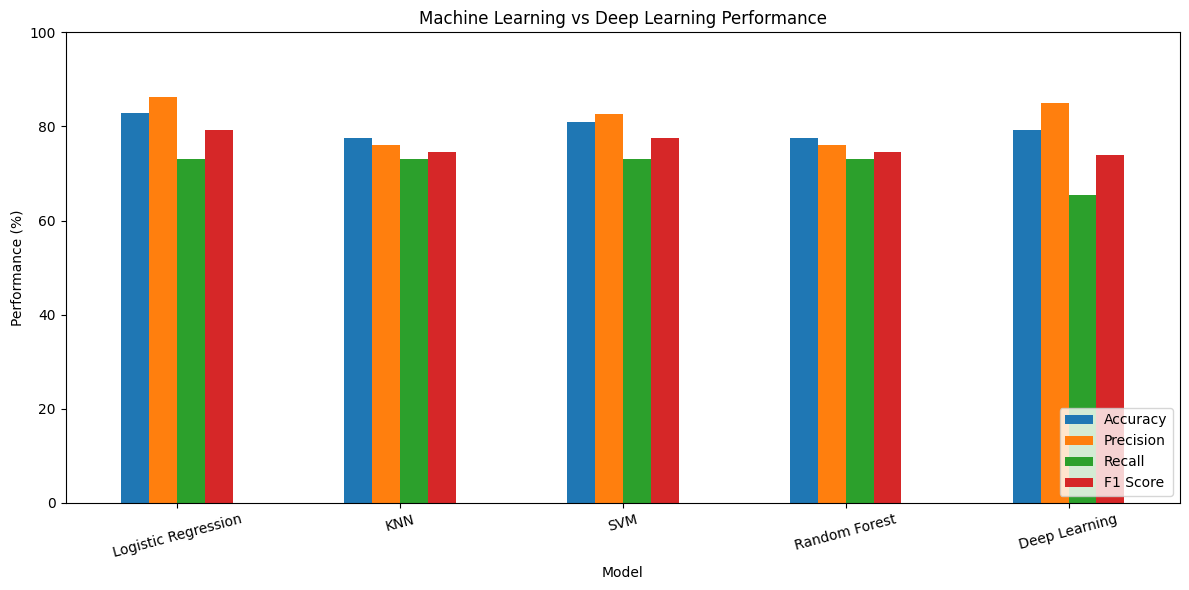


STEP 16: DEEP LEARNING CONFUSION MATRIX

Confusion Matrix:
[[29  3]
 [ 9 17]]


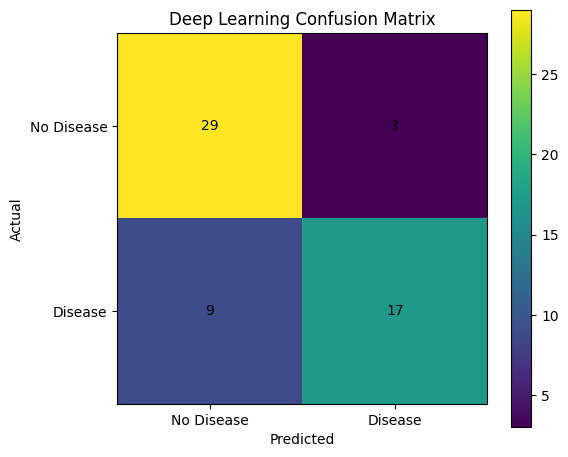


STEP 17: DEEP LEARNING CLASSIFICATION REPORT
                  precision    recall  f1-score   support

No Heart Disease       0.76      0.91      0.83        32
   Heart Disease       0.85      0.65      0.74        26

        accuracy                           0.79        58
       macro avg       0.81      0.78      0.78        58
    weighted avg       0.80      0.79      0.79        58


STEP 18: FEATURE IMPORTANCE

Feature Importance:

 Feature  Importance
    thal    0.153730
      cp    0.123014
 thalach    0.119553
 oldpeak    0.099573
      ca    0.089197
     age    0.086317
    chol    0.080948
trestbps    0.077386
   exang    0.055525
     sex    0.045867
   slope    0.043211
 restecg    0.019550
     fbs    0.006128


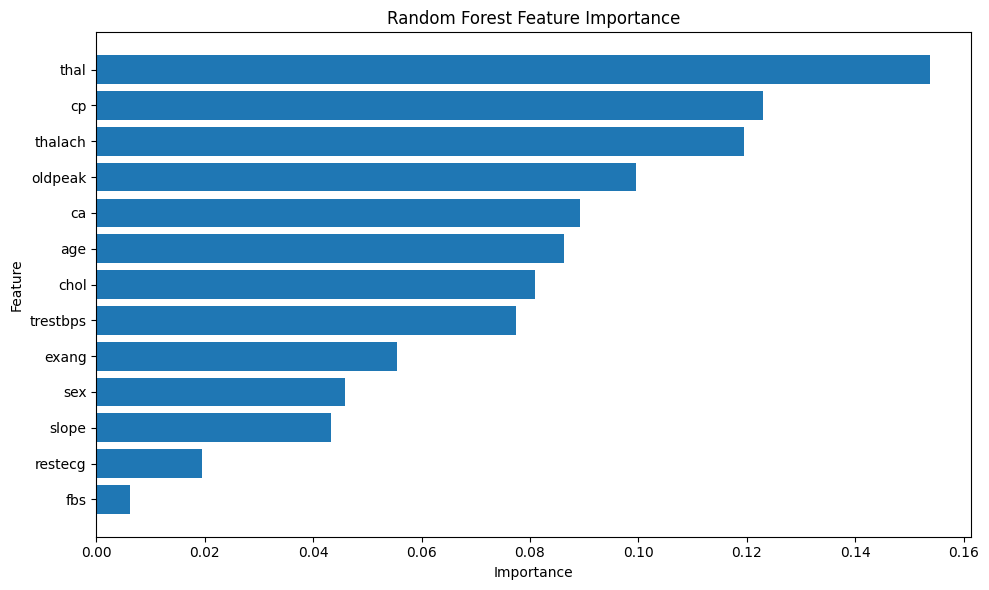


STEP 19: SAMPLE PATIENT PREDICTION

PATIENT PREDICTION RESULT
--------------------------------------------------
Prediction: HEART DISEASE DETECTED

Probability of Heart Disease: 80.28%
Probability of No Heart Disease: 19.72%


SHREYAS - PAPER 3 FINAL RESULT

Paper:
Prediction of Heart Disease Using a Combination of Machine Learning and Deep Learning

Authors:
Robit Bharti, Aditya Khampania, Mohammad Shabaz, Gaurav Dhiman, Sagar Pande & Parneet Singh (2021)

Dataset:
UCI Cleveland Heart Disease Dataset

Preprocessing:
1. Missing Value Handling
2. Isolation Forest
3. Outlier Removal
4. Data Normalization

Machine Learning Models:
1. Logistic Regression
2. KNN
3. Support Vector Machine
4. Random Forest

Deep Learning:
Artificial Neural Network

---------------------------------------------------------------------------
OUR EXPERIMENTAL RESULTS
---------------------------------------------------------------------------
Logistic Regression : 82.76%
KNN                 : 77.59%
SVM        

In [ ]:
# =====================================================================
# SHREYAS - PAPER 3
#
# Prediction of Heart Disease Using a Combination of
# Machine Learning and Deep Learning
# =====================================================================


# =====================================================================
# 1. IMPORT LIBRARIES
# =====================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import (
    RandomForestClassifier,
    IsolationForest
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import EarlyStopping


# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)


print("=" * 75)
print("SHREYAS - PAPER 3")
print("HEART DISEASE PREDICTION USING ML + DEEP LEARNING")
print("=" * 75)

print("\nAll libraries imported successfully!")


# =====================================================================
# 2. LOAD UCI HEART DISEASE DATASET
# =====================================================================

print("\n" + "=" * 75)
print("STEP 1: LOADING UCI HEART DISEASE DATASET")
print("=" * 75)


columns = [

    'age',
    'sex',
    'cp',
    'trestbps',
    'chol',
    'fbs',
    'restecg',
    'thalach',
    'exang',
    'oldpeak',
    'slope',
    'ca',
    'thal',
    'target'

]


url = (
    "https://archive.ics.uci.edu/ml/"
    "machine-learning-databases/heart-disease/"
    "processed.cleveland.data"
)


df = pd.read_csv(

    url,

    names=columns,

    na_values='?'

)


print("\nDataset loaded successfully!")

print("\nDataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())


# =====================================================================
# 3. CONVERT TARGET TO BINARY
# =====================================================================

print("\n" + "=" * 75)
print("STEP 2: TARGET CONVERSION")
print("=" * 75)


# Original UCI:
#
# 0       = No Heart Disease
# 1,2,3,4 = Heart Disease
#
# Convert:
#
# 0 = No Heart Disease
# 1 = Heart Disease


df['target'] = (

    df['target'] > 0

).astype(int)


print("\nTarget converted successfully!")

print("\nTarget Distribution:")

print(

    df['target'].value_counts()

)


# =====================================================================
# 4. CHECK MISSING VALUES
# =====================================================================

print("\n" + "=" * 75)
print("STEP 3: CHECKING MISSING VALUES")
print("=" * 75)


print("\nMissing Values:")

print(

    df.isnull().sum()

)


# =====================================================================
# 5. HANDLE MISSING VALUES
# =====================================================================

print("\n" + "=" * 75)
print("STEP 4: HANDLING MISSING VALUES")
print("=" * 75)


for column in df.columns:

    if df[column].isnull().sum() > 0:

        median_value = (

            df[column].median()

        )

        df[column] = (

            df[column]
            .fillna(median_value)

        )

        print(

            f"{column}: Missing values replaced "
            f"with median = {median_value:.2f}"

        )


print("\nMissing values after preprocessing:")

print(

    df.isnull().sum()

)


# =====================================================================
# 6. SEPARATE FEATURES AND TARGET
# =====================================================================

print("\n" + "=" * 75)
print("STEP 5: SEPARATING FEATURES AND TARGET")
print("=" * 75)


X = df.drop(

    'target',

    axis=1

)


y = df['target']


print("\nInput Shape:")

print(X.shape)


print("\nTarget Shape:")

print(y.shape)


print("\nFeatures:")

for feature in X.columns:

    print("-", feature)


# =====================================================================
# 7. ISOLATION FOREST
# =====================================================================

print("\n" + "=" * 75)
print("STEP 6: ISOLATION FOREST OUTLIER DETECTION")
print("=" * 75)


# Isolation Forest identifies unusual/anomalous rows.
#
# 1  = Normal
# -1 = Outlier


isolation_forest = IsolationForest(

    contamination=0.05,

    random_state=42

)


outlier_labels = (

    isolation_forest.fit_predict(X)

)


print("\nIsolation Forest completed!")


normal_count = (

    np.sum(outlier_labels == 1)

)


outlier_count = (

    np.sum(outlier_labels == -1)

)


print(

    "\nNormal Samples:",

    normal_count

)


print(

    "Detected Outliers:",

    outlier_count

)


# =====================================================================
# 8. REMOVE OUTLIERS
# =====================================================================

X_clean = (

    X[outlier_labels == 1]
    .copy()

)


y_clean = (

    y[outlier_labels == 1]
    .copy()

)


# Reset index

X_clean.reset_index(

    drop=True,

    inplace=True

)


y_clean.reset_index(

    drop=True,

    inplace=True

)


print("\nOriginal Dataset Size:")

print(

    X.shape[0]

)


print("\nDataset Size After Isolation Forest:")

print(

    X_clean.shape[0]

)


# =====================================================================
# 9. TRAIN TEST SPLIT
# =====================================================================

print("\n" + "=" * 75)
print("STEP 7: TRAIN-TEST SPLIT")
print("=" * 75)


X_train, X_test, y_train, y_test = train_test_split(

    X_clean,

    y_clean,

    test_size=0.20,

    random_state=42,

    stratify=y_clean

)


print(

    "\nTraining Samples:",

    X_train.shape[0]

)


print(

    "Testing Samples:",

    X_test.shape[0]

)


# =====================================================================
# 10. NORMALIZATION / STANDARDIZATION
# =====================================================================

print("\n" + "=" * 75)
print("STEP 8: DATA NORMALIZATION")
print("=" * 75)


scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(

    X_train

)


X_test_scaled = scaler.transform(

    X_test

)


print("\nNormalization completed successfully!")


# =====================================================================
# 11. METRIC FUNCTION
# =====================================================================

def calculate_metrics(

    actual,

    predicted

):

    accuracy = accuracy_score(

        actual,

        predicted

    )


    precision = precision_score(

        actual,

        predicted,

        zero_division=0

    )


    recall = recall_score(

        actual,

        predicted,

        zero_division=0

    )


    f1 = f1_score(

        actual,

        predicted,

        zero_division=0

    )


    return (

        accuracy,

        precision,

        recall,

        f1

    )


# =====================================================================
# 12. LOGISTIC REGRESSION
# =====================================================================

print("\n" + "=" * 75)
print("STEP 9: LOGISTIC REGRESSION")
print("=" * 75)


lr_model = LogisticRegression(

    max_iter=2000,

    random_state=42

)


lr_model.fit(

    X_train_scaled,

    y_train

)


lr_prediction = lr_model.predict(

    X_test_scaled

)


lr_metrics = calculate_metrics(

    y_test,

    lr_prediction

)


print(

    f"\nLogistic Regression Accuracy: "
    f"{lr_metrics[0] * 100:.2f}%"

)


# =====================================================================
# 13. KNN
# =====================================================================

print("\n" + "=" * 75)
print("STEP 10: K-NEAREST NEIGHBORS")
print("=" * 75)


knn_model = KNeighborsClassifier(

    n_neighbors=5

)


knn_model.fit(

    X_train_scaled,

    y_train

)


knn_prediction = knn_model.predict(

    X_test_scaled

)


knn_metrics = calculate_metrics(

    y_test,

    knn_prediction

)


print(

    f"\nKNN Accuracy: "
    f"{knn_metrics[0] * 100:.2f}%"

)


# =====================================================================
# 14. SVM
# =====================================================================

print("\n" + "=" * 75)
print("STEP 11: SUPPORT VECTOR MACHINE")
print("=" * 75)


svm_model = SVC(

    kernel='rbf',

    probability=True,

    random_state=42

)


svm_model.fit(

    X_train_scaled,

    y_train

)


svm_prediction = svm_model.predict(

    X_test_scaled

)


svm_metrics = calculate_metrics(

    y_test,

    svm_prediction

)


print(

    f"\nSVM Accuracy: "
    f"{svm_metrics[0] * 100:.2f}%"

)


# =====================================================================
# 15. RANDOM FOREST
# =====================================================================

print("\n" + "=" * 75)
print("STEP 12: RANDOM FOREST")
print("=" * 75)


rf_model = RandomForestClassifier(

    n_estimators=200,

    random_state=42

)


rf_model.fit(

    X_train,

    y_train

)


rf_prediction = rf_model.predict(

    X_test

)


rf_metrics = calculate_metrics(

    y_test,

    rf_prediction

)


print(

    f"\nRandom Forest Accuracy: "
    f"{rf_metrics[0] * 100:.2f}%"

)


# =====================================================================
# 16. DEEP LEARNING MODEL
# =====================================================================

print("\n" + "=" * 75)
print("STEP 13: BUILDING DEEP LEARNING MODEL")
print("=" * 75)


deep_model = Sequential([

    # Input + Hidden Layer 1

    Dense(

        64,

        activation='relu',

        input_shape=(

            X_train_scaled.shape[1],

        )

    ),


    Dropout(0.20),


    # Hidden Layer 2

    Dense(

        32,

        activation='relu'

    ),


    Dropout(0.20),


    # Hidden Layer 3

    Dense(

        16,

        activation='relu'

    ),


    # Output Layer

    Dense(

        1,

        activation='sigmoid'

    )

])


deep_model.compile(

    optimizer='adam',

    loss='binary_crossentropy',

    metrics=['accuracy']

)


print("\nDeep Learning Architecture:")

deep_model.summary()


# =====================================================================
# 17. EARLY STOPPING
# =====================================================================

early_stopping = EarlyStopping(

    monitor='val_loss',

    patience=15,

    restore_best_weights=True

)


# =====================================================================
# 18. TRAIN DEEP LEARNING MODEL
# =====================================================================

print("\n" + "=" * 75)
print("STEP 14: TRAINING DEEP LEARNING MODEL")
print("=" * 75)


history = deep_model.fit(

    X_train_scaled,

    y_train,

    validation_split=0.20,

    epochs=150,

    batch_size=16,

    callbacks=[

        early_stopping

    ],

    verbose=0

)


print("\nDeep Learning Model Training Completed!")


print(

    "Epochs Used:",

    len(history.history['loss'])

)


# =====================================================================
# 19. DEEP LEARNING PREDICTION
# =====================================================================

deep_probability = (

    deep_model.predict(

        X_test_scaled,

        verbose=0

    )

    .flatten()

)


deep_prediction = (

    deep_probability >= 0.5

).astype(int)


deep_metrics = calculate_metrics(

    y_test,

    deep_prediction

)


print(

    f"\nDeep Learning Accuracy: "
    f"{deep_metrics[0] * 100:.2f}%"

)


# =====================================================================
# 20. TRAINING AND VALIDATION ACCURACY GRAPH
# =====================================================================

plt.figure(

    figsize=(9, 5)

)


plt.plot(

    history.history['accuracy'],

    label='Training Accuracy'

)


plt.plot(

    history.history['val_accuracy'],

    label='Validation Accuracy'

)


plt.title(

    "Deep Learning Training and Validation Accuracy"

)


plt.xlabel(

    "Epoch"

)


plt.ylabel(

    "Accuracy"

)


plt.legend()


plt.tight_layout()


plt.show()


# =====================================================================
# 21. TRAINING / VALIDATION LOSS GRAPH
# =====================================================================

plt.figure(

    figsize=(9, 5)

)


plt.plot(

    history.history['loss'],

    label='Training Loss'

)


plt.plot(

    history.history['val_loss'],

    label='Validation Loss'

)


plt.title(

    "Deep Learning Training and Validation Loss"

)


plt.xlabel(

    "Epoch"

)


plt.ylabel(

    "Loss"

)


plt.legend()


plt.tight_layout()


plt.show()


# =====================================================================
# 22. CREATE MODEL COMPARISON TABLE
# =====================================================================

print("\n" + "=" * 75)
print("STEP 15: MACHINE LEARNING VS DEEP LEARNING")
print("=" * 75)


results = pd.DataFrame({

    'Model': [

        'Logistic Regression',

        'KNN',

        'SVM',

        'Random Forest',

        'Deep Learning'

    ],


    'Accuracy': [

        lr_metrics[0] * 100,

        knn_metrics[0] * 100,

        svm_metrics[0] * 100,

        rf_metrics[0] * 100,

        deep_metrics[0] * 100

    ],


    'Precision': [

        lr_metrics[1] * 100,

        knn_metrics[1] * 100,

        svm_metrics[1] * 100,

        rf_metrics[1] * 100,

        deep_metrics[1] * 100

    ],


    'Recall': [

        lr_metrics[2] * 100,

        knn_metrics[2] * 100,

        svm_metrics[2] * 100,

        rf_metrics[2] * 100,

        deep_metrics[2] * 100

    ],


    'F1 Score': [

        lr_metrics[3] * 100,

        knn_metrics[3] * 100,

        svm_metrics[3] * 100,

        rf_metrics[3] * 100,

        deep_metrics[3] * 100

    ]

})


results[

    [

        'Accuracy',

        'Precision',

        'Recall',

        'F1 Score'

    ]

] = results[

    [

        'Accuracy',

        'Precision',

        'Recall',

        'F1 Score'

    ]

].round(2)


print("\nMODEL COMPARISON\n")


print(

    results.to_string(

        index=False

    )

)


# =====================================================================
# 23. MODEL COMPARISON GRAPH
# =====================================================================

results.set_index(

    'Model'

)[

    [

        'Accuracy',

        'Precision',

        'Recall',

        'F1 Score'

    ]

].plot(

    kind='bar',

    figsize=(12, 6)

)


plt.title(

    "Machine Learning vs Deep Learning Performance"

)


plt.xlabel(

    "Model"

)


plt.ylabel(

    "Performance (%)"

)


plt.ylim(

    0,

    100

)


plt.xticks(

    rotation=15

)


plt.legend(

    loc='lower right'

)


plt.tight_layout()


plt.show()


# =====================================================================
# 24. DEEP LEARNING CONFUSION MATRIX
# =====================================================================

print("\n" + "=" * 75)
print("STEP 16: DEEP LEARNING CONFUSION MATRIX")
print("=" * 75)


dl_cm = confusion_matrix(

    y_test,

    deep_prediction

)


print("\nConfusion Matrix:")

print(dl_cm)


plt.figure(

    figsize=(6, 5)

)


plt.imshow(

    dl_cm,

    interpolation='nearest'

)


plt.title(

    "Deep Learning Confusion Matrix"

)


plt.xlabel(

    "Predicted"

)


plt.ylabel(

    "Actual"

)


plt.xticks(

    [0, 1],

    [

        'No Disease',

        'Disease'

    ]

)


plt.yticks(

    [0, 1],

    [

        'No Disease',

        'Disease'

    ]

)


for i in range(2):

    for j in range(2):

        plt.text(

            j,

            i,

            dl_cm[i, j],

            horizontalalignment='center',

            verticalalignment='center'

        )


plt.colorbar()


plt.tight_layout()


plt.show()


# =====================================================================
# 25. DEEP LEARNING CLASSIFICATION REPORT
# =====================================================================

print("\n" + "=" * 75)
print("STEP 17: DEEP LEARNING CLASSIFICATION REPORT")
print("=" * 75)


print(

    classification_report(

        y_test,

        deep_prediction,

        target_names=[

            'No Heart Disease',

            'Heart Disease'

        ]

    )

)


# =====================================================================
# 26. RANDOM FOREST FEATURE IMPORTANCE
# =====================================================================

print("\n" + "=" * 75)
print("STEP 18: FEATURE IMPORTANCE")
print("=" * 75)


feature_importance = pd.DataFrame({

    'Feature':

        X_train.columns,


    'Importance':

        rf_model.feature_importances_

})


feature_importance = (

    feature_importance

    .sort_values(

        by='Importance',

        ascending=False

    )

)


print("\nFeature Importance:\n")


print(

    feature_importance.to_string(

        index=False

    )

)


# =====================================================================
# 27. FEATURE IMPORTANCE GRAPH
# =====================================================================

plt.figure(

    figsize=(10, 6)

)


plt.barh(

    feature_importance['Feature'],

    feature_importance['Importance']

)


plt.title(

    "Random Forest Feature Importance"

)


plt.xlabel(

    "Importance"

)


plt.ylabel(

    "Feature"

)


plt.gca().invert_yaxis()


plt.tight_layout()


plt.show()


# =====================================================================
# 28. SAMPLE PATIENT PREDICTION USING DEEP LEARNING
# =====================================================================

print("\n" + "=" * 75)
print("STEP 19: SAMPLE PATIENT PREDICTION")
print("=" * 75)


new_patient = pd.DataFrame([{

    'age': 57,

    'sex': 1,

    'cp': 4,

    'trestbps': 140,

    'chol': 241,

    'fbs': 0,

    'restecg': 0,

    'thalach': 123,

    'exang': 1,

    'oldpeak': 0.2,

    'slope': 2,

    'ca': 0,

    'thal': 7

}])


# Apply the SAME scaler used for training

new_patient_scaled = scaler.transform(

    new_patient

)


patient_probability = (

    deep_model.predict(

        new_patient_scaled,

        verbose=0

    )[0][0]

)


patient_prediction = (

    1

    if patient_probability >= 0.5

    else 0

)


print("\nPATIENT PREDICTION RESULT")

print("-" * 50)


if patient_prediction == 1:

    print(

        "Prediction: HEART DISEASE DETECTED"

    )

else:

    print(

        "Prediction: NO HEART DISEASE DETECTED"

    )


print(

    f"\nProbability of Heart Disease: "
    f"{patient_probability * 100:.2f}%"

)


print(

    f"Probability of No Heart Disease: "
    f"{(1 - patient_probability) * 100:.2f}%"

)


# =====================================================================
# 29. FIND BEST MODEL
# =====================================================================

best_model_index = (

    results['Accuracy'].idxmax()

)


best_model = (

    results.loc[best_model_index]

)


# =====================================================================
# 30. FINAL SUMMARY
# =====================================================================

print("\n")
print("=" * 75)
print("SHREYAS - PAPER 3 FINAL RESULT")
print("=" * 75)


print("\nPaper:")

print(

    "Prediction of Heart Disease Using a Combination "
    "of Machine Learning and Deep Learning"

)


print("\nAuthors:")

print(

    "Robit Bharti, Aditya Khampania, Mohammad Shabaz, "
    "Gaurav Dhiman, Sagar Pande & Parneet Singh (2021)"

)


print("\nDataset:")

print(

    "UCI Cleveland Heart Disease Dataset"

)


print("\nPreprocessing:")

print(

    "1. Missing Value Handling"

)

print(

    "2. Isolation Forest"

)

print(

    "3. Outlier Removal"

)

print(

    "4. Data Normalization"

)


print("\nMachine Learning Models:")

print(

    "1. Logistic Regression"

)

print(

    "2. KNN"

)

print(

    "3. Support Vector Machine"

)

print(

    "4. Random Forest"

)


print("\nDeep Learning:")

print(

    "Artificial Neural Network"

)


print("\n" + "-" * 75)

print("OUR EXPERIMENTAL RESULTS")

print("-" * 75)


print(

    f"Logistic Regression : "
    f"{lr_metrics[0] * 100:.2f}%"

)


print(

    f"KNN                 : "
    f"{knn_metrics[0] * 100:.2f}%"

)


print(

    f"SVM                 : "
    f"{svm_metrics[0] * 100:.2f}%"

)


print(

    f"Random Forest       : "
    f"{rf_metrics[0] * 100:.2f}%"

)


print(

    f"Deep Learning       : "
    f"{deep_metrics[0] * 100:.2f}%"

)


print("\nBest Model in This Run:")

print(

    best_model['Model']

)


print(

    f"Best Accuracy: "
    f"{best_model['Accuracy']:.2f}%"

)


print("\n" + "-" * 75)

print("PAPER REPORTED RESULT")

print("-" * 75)


print(

    "Paper Main Method: Deep Learning Model"

)


print(

    "Paper Reported Accuracy: Approximately 94.2%"

)


print(

    "\nNOTE: The accuracy obtained in this Colab run "
    "may differ from the paper's 94.2% because the "
    "exact experimental setup, preprocessing, "
    "train/test split and neural-network configuration "
    "can differ."

)


print("\n" + "=" * 75)

print(

    "PAPER 3 IMPLEMENTATION COMPLETED SUCCESSFULLY!"

)

print("=" * 75)

SHREYAS - PAPER 4
HEART DISEASE PREDICTION USING ARTIFICIAL NEURAL NETWORK

All libraries imported successfully!

STEP 1: LOADING HEART DISEASE DATASET

Dataset loaded successfully!

Dataset Shape:
(303, 14)

First 5 Rows:
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       2  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  

STEP 2: DATASET INFORMATION

Dataset Columns:
- age
- sex
- cp
- trestbps
- chol
- fbs
- restecg
- thalach
- exang
- oldpeak
- slope


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,521 (13.75 KB)

 Trainable params: 3,521 (13.75 KB)

...

 Trainable params: 13,121 (51.25 KB)

 Non-trainable params: 448 (1.75 KB)


STEP 13: TRAINING IMPROVED DEEP ANN



Improved ANN Training Completed Successfully!
Epochs Used: 30

STEP 14: MAKING PREDICTIONS



Predictions completed successfully!

STEP 15: IMPROVED ANN PERFORMANCE

Accuracy  : 83.61%
Precision : 82.14%
Recall    : 82.14%
F1 Score  : 82.14%
ROC-AUC   : 0.9297

STEP 16: BASIC ANN VS IMPROVED ANN

ANN COMPARISON

                    Model  Accuracy  Precision  Recall  F1 Score
                Basic ANN     90.16      89.29   89.29     89.29
ANN + BatchNorm + Dropout     83.61      82.14   82.14     82.14


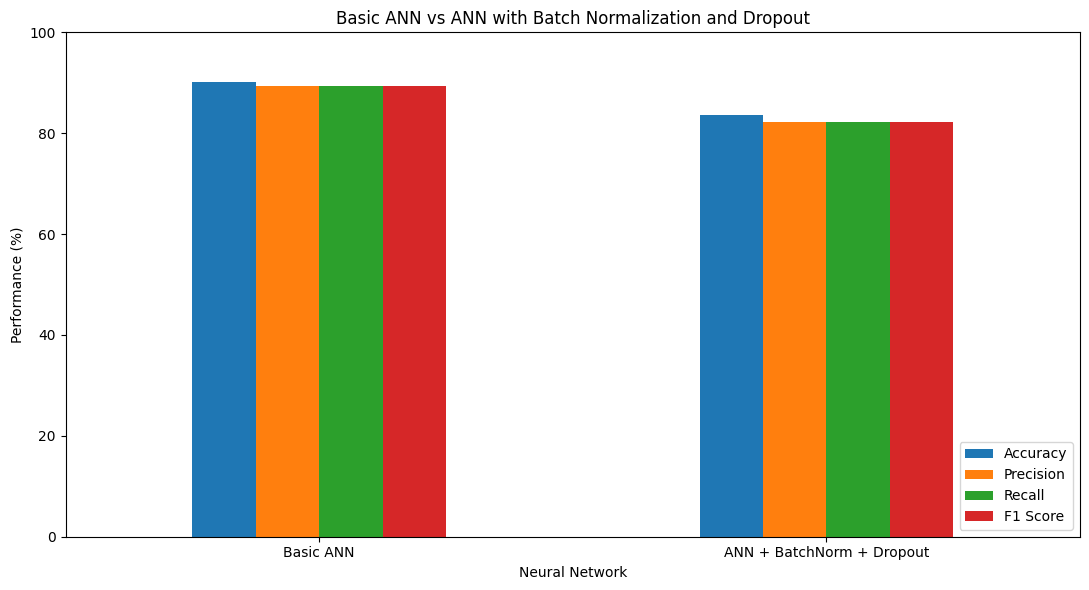

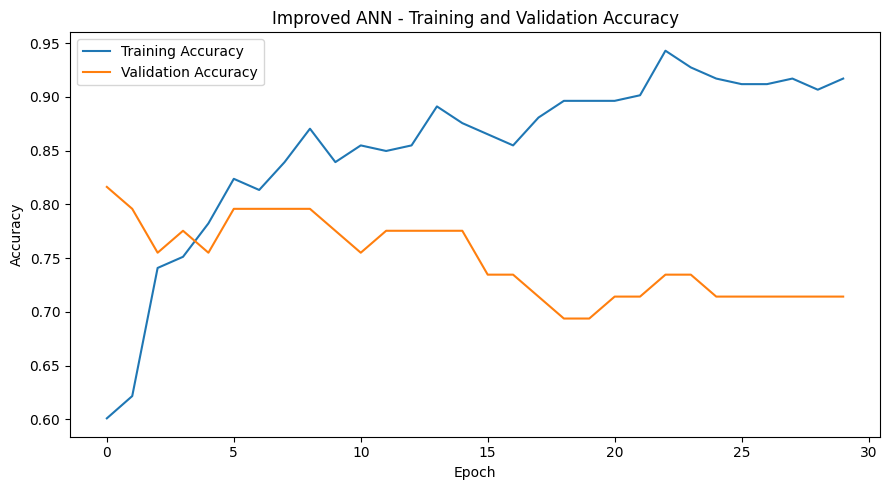

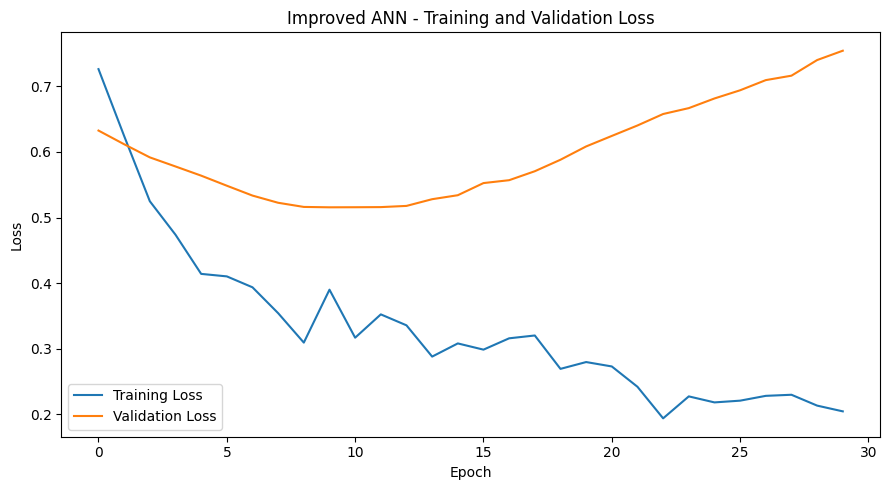


STEP 17: CONFUSION MATRIX

Confusion Matrix:
[[28  5]
 [ 5 23]]


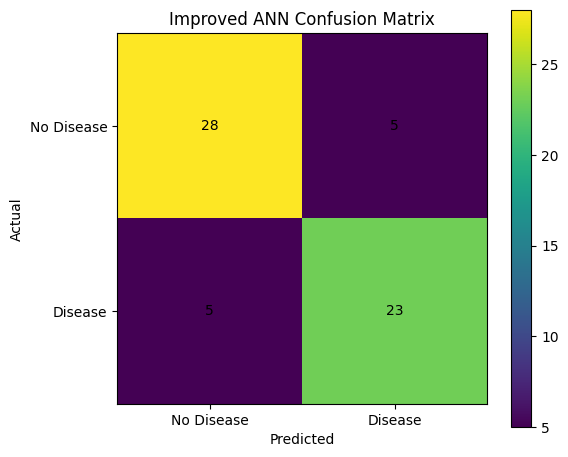


STEP 18: CLASSIFICATION REPORT
                  precision    recall  f1-score   support

No Heart Disease       0.85      0.85      0.85        33
   Heart Disease       0.82      0.82      0.82        28

        accuracy                           0.84        61
       macro avg       0.83      0.83      0.83        61
    weighted avg       0.84      0.84      0.84        61


STEP 19: ROC CURVE


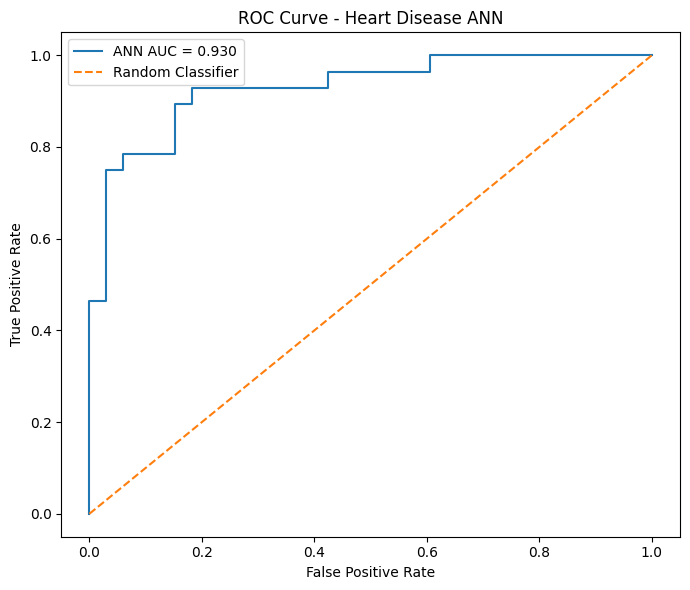


STEP 20: SAMPLE PATIENT PREDICTION

PATIENT PREDICTION RESULT
--------------------------------------------------
Prediction: HEART DISEASE DETECTED

Heart Disease Probability: 66.55%
No Heart Disease Probability: 33.45%


SHREYAS - PAPER 4 FINAL RESULT

Paper:
Heart Disease Prediction Using Artificial Neural Networks

Authors:
K. Vinay Varma et al. (2024)

Dataset:
UCI Cleveland Heart Disease Dataset

Preprocessing:
1. Missing Value Handling
2. Duplicate Removal
3. Train-Test Split
4. Feature Standardization

Deep Learning Architecture:
Input Layer
       ↓
Dense Layer (128)
       ↓
Batch Normalization
       ↓
Dropout
       ↓
Dense Layer (64)
       ↓
Batch Normalization
       ↓
Dropout
       ↓
Dense Layer (32)
       ↓
Batch Normalization
       ↓
Dropout
       ↓
Dense Layer (16)
       ↓
Sigmoid Output

---------------------------------------------------------------------------
OUR EXPERIMENTAL RESULTS
---------------------------------------------------------------------------

In [ ]:
# =====================================================================
# SHREYAS - PAPER 4
# HEART DISEASE PREDICTION USING ARTIFICIAL NEURAL NETWORKS
# Deep ANN + Batch Normalization + Dropout
# =====================================================================


# =====================================================================
# 1. IMPORT LIBRARIES
# =====================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.callbacks import EarlyStopping


# =====================================================================
# REPRODUCIBILITY
# =====================================================================

np.random.seed(42)

tf.random.set_seed(42)


print("=" * 75)
print("SHREYAS - PAPER 4")
print("HEART DISEASE PREDICTION USING ARTIFICIAL NEURAL NETWORK")
print("=" * 75)

print("\nAll libraries imported successfully!")


# =====================================================================
# 2. LOAD UCI HEART DISEASE DATASET
# =====================================================================

print("\n" + "=" * 75)
print("STEP 1: LOADING HEART DISEASE DATASET")
print("=" * 75)


columns = [

    'age',
    'sex',
    'cp',
    'trestbps',
    'chol',
    'fbs',
    'restecg',
    'thalach',
    'exang',
    'oldpeak',
    'slope',
    'ca',
    'thal',
    'target'

]


url = (
    "https://archive.ics.uci.edu/ml/"
    "machine-learning-databases/heart-disease/"
    "processed.cleveland.data"
)


df = pd.read_csv(
    url,
    names=columns,
    na_values='?'
)


print("\nDataset loaded successfully!")

print("\nDataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())


# =====================================================================
# 3. DATASET INFORMATION
# =====================================================================

print("\n" + "=" * 75)
print("STEP 2: DATASET INFORMATION")
print("=" * 75)


print("\nDataset Columns:")

for column in df.columns:

    print("-", column)


print("\nDataset Statistical Summary:")

print(df.describe())


# =====================================================================
# 4. CONVERT TARGET INTO BINARY CLASSIFICATION
# =====================================================================

print("\n" + "=" * 75)
print("STEP 3: TARGET CONVERSION")
print("=" * 75)


# Original UCI target:
#
# 0       = No Heart Disease
# 1,2,3,4 = Heart Disease
#
# Convert into:
#
# 0 = No Heart Disease
# 1 = Heart Disease


df['target'] = (
    df['target'] > 0
).astype(int)


print("\nTarget converted successfully!")

print("\nTarget Distribution:")

print(
    df['target'].value_counts()
)


print("\nPercentage Distribution:")

print(
    (
        df['target']
        .value_counts(normalize=True)
        * 100
    ).round(2)
)


# =====================================================================
# 5. CHECK MISSING VALUES
# =====================================================================

print("\n" + "=" * 75)
print("STEP 4: CHECKING MISSING VALUES")
print("=" * 75)


print("\nMissing Values Before Preprocessing:")

print(
    df.isnull().sum()
)


# =====================================================================
# 6. HANDLE MISSING VALUES
# =====================================================================

print("\n" + "=" * 75)
print("STEP 5: HANDLING MISSING VALUES")
print("=" * 75)


# Replace missing values using median.
#
# Median is robust when a feature contains
# unusually high or low values.


for column in df.columns:

    if df[column].isnull().sum() > 0:

        median_value = df[column].median()

        df[column] = df[column].fillna(
            median_value
        )

        print(
            f"{column}: Missing values replaced "
            f"with median = {median_value:.2f}"
        )


print("\nMissing Values After Preprocessing:")

print(
    df.isnull().sum()
)


# =====================================================================
# 7. CHECK DUPLICATE ROWS
# =====================================================================

print("\n" + "=" * 75)
print("STEP 6: CHECKING DUPLICATES")
print("=" * 75)


duplicate_count = df.duplicated().sum()


print(
    "\nDuplicate Rows Found:",
    duplicate_count
)


if duplicate_count > 0:

    df = df.drop_duplicates()

    df = df.reset_index(
        drop=True
    )

    print(
        "Duplicate rows removed successfully!"
    )

else:

    print(
        "No duplicate rows found."
    )


print(
    "\nDataset Shape After Cleaning:",
    df.shape
)


# =====================================================================
# 8. SEPARATE FEATURES AND TARGET
# =====================================================================

print("\n" + "=" * 75)
print("STEP 7: SEPARATING INPUT AND OUTPUT")
print("=" * 75)


X = df.drop(
    'target',
    axis=1
)


y = df['target']


print("\nInput Feature Shape:")

print(X.shape)


print("\nTarget Shape:")

print(y.shape)


print("\nInput Features:")

for feature in X.columns:

    print("-", feature)


# =====================================================================
# 9. TRAIN-TEST SPLIT
# =====================================================================

print("\n" + "=" * 75)
print("STEP 8: TRAIN-TEST SPLIT")
print("=" * 75)


X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)


print(
    "\nTraining Samples:",
    X_train.shape[0]
)


print(
    "Testing Samples:",
    X_test.shape[0]
)


print(
    "\nTraining Shape:",
    X_train.shape
)


print(
    "Testing Shape:",
    X_test.shape
)


# =====================================================================
# 10. STANDARDIZE THE DATA
# =====================================================================

print("\n" + "=" * 75)
print("STEP 9: FEATURE STANDARDIZATION")
print("=" * 75)


scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(
    X_train
)


X_test_scaled = scaler.transform(
    X_test
)


print(
    "\nFeature Standardization completed successfully!"
)


print(
    "\nMean of standardized training data:",
    round(X_train_scaled.mean(), 4)
)


print(
    "Standard deviation:",
    round(X_train_scaled.std(), 4)
)


# =====================================================================
# 11. CREATE BASIC ANN
# =====================================================================

print("\n" + "=" * 75)
print("STEP 10: BUILDING BASIC ANN")
print("=" * 75)


# We first create a basic ANN.
#
# Later we will compare this with an improved
# ANN containing Batch Normalization + Dropout.


basic_ann = Sequential([

    Input(
        shape=(X_train_scaled.shape[1],)
    ),

    Dense(
        64,
        activation='relu'
    ),

    Dense(
        32,
        activation='relu'
    ),

    Dense(
        16,
        activation='relu'
    ),

    Dense(
        1,
        activation='sigmoid'
    )

])


basic_ann.compile(

    optimizer='adam',

    loss='binary_crossentropy',

    metrics=['accuracy']

)


print("\nBasic ANN Architecture:")

basic_ann.summary()


# =====================================================================
# 12. TRAIN BASIC ANN
# =====================================================================

print("\n" + "=" * 75)
print("STEP 11: TRAINING BASIC ANN")
print("=" * 75)


basic_early_stopping = EarlyStopping(

    monitor='val_loss',

    patience=15,

    restore_best_weights=True

)


basic_history = basic_ann.fit(

    X_train_scaled,

    y_train,

    validation_split=0.20,

    epochs=150,

    batch_size=16,

    callbacks=[
        basic_early_stopping
    ],

    verbose=0

)


print(
    "\nBasic ANN Training Completed!"
)


print(
    "Epochs Used:",
    len(basic_history.history['loss'])
)


# =====================================================================
# 13. BASIC ANN PREDICTION
# =====================================================================

basic_probability = basic_ann.predict(

    X_test_scaled,

    verbose=0

).flatten()


basic_prediction = (

    basic_probability >= 0.5

).astype(int)


basic_accuracy = accuracy_score(

    y_test,

    basic_prediction

)


basic_precision = precision_score(

    y_test,

    basic_prediction,

    zero_division=0

)


basic_recall = recall_score(

    y_test,

    basic_prediction,

    zero_division=0

)


basic_f1 = f1_score(

    y_test,

    basic_prediction,

    zero_division=0

)


print(
    f"\nBasic ANN Accuracy: "
    f"{basic_accuracy * 100:.2f}%"
)


# =====================================================================
# 14. CREATE IMPROVED DEEP ANN
# =====================================================================

print("\n" + "=" * 75)
print("STEP 12: BUILDING IMPROVED DEEP ANN")
print("=" * 75)


# ============================================================
# IMPORTANT PAPER 4 ARCHITECTURE
#
# Dense Layer
#      ↓
# Batch Normalization
#      ↓
# Dropout
#      ↓
# Dense Layer
#      ↓
# Batch Normalization
#      ↓
# Dropout
#      ↓
# Dense Layer
#      ↓
# Batch Normalization
#      ↓
# Dropout
#      ↓
# Sigmoid Output
#
# Batch Normalization:
# Helps stabilize and speed up training.
#
# Dropout:
# Helps reduce overfitting.
# ============================================================


improved_ann = Sequential([

    # ---------------------------------------------------------
    # INPUT
    # ---------------------------------------------------------

    Input(
        shape=(X_train_scaled.shape[1],)
    ),


    # ---------------------------------------------------------
    # HIDDEN LAYER 1
    # ---------------------------------------------------------

    Dense(
        128,
        activation='relu'
    ),

    BatchNormalization(),

    Dropout(0.30),


    # ---------------------------------------------------------
    # HIDDEN LAYER 2
    # ---------------------------------------------------------

    Dense(
        64,
        activation='relu'
    ),

    BatchNormalization(),

    Dropout(0.30),


    # ---------------------------------------------------------
    # HIDDEN LAYER 3
    # ---------------------------------------------------------

    Dense(
        32,
        activation='relu'
    ),

    BatchNormalization(),

    Dropout(0.20),


    # ---------------------------------------------------------
    # HIDDEN LAYER 4
    # ---------------------------------------------------------

    Dense(
        16,
        activation='relu'
    ),

    Dropout(0.10),


    # ---------------------------------------------------------
    # OUTPUT
    # ---------------------------------------------------------

    Dense(
        1,
        activation='sigmoid'
    )

])


# =====================================================================
# 15. COMPILE IMPROVED ANN
# =====================================================================

improved_ann.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss='binary_crossentropy',

    metrics=[
        'accuracy'
    ]

)


print("\nImproved ANN Architecture:")

improved_ann.summary()


# =====================================================================
# 16. EARLY STOPPING
# =====================================================================

early_stopping = EarlyStopping(

    monitor='val_loss',

    patience=20,

    restore_best_weights=True

)


# =====================================================================
# 17. TRAIN IMPROVED ANN
# =====================================================================

print("\n" + "=" * 75)
print("STEP 13: TRAINING IMPROVED DEEP ANN")
print("=" * 75)


history = improved_ann.fit(

    X_train_scaled,

    y_train,

    validation_split=0.20,

    epochs=200,

    batch_size=16,

    callbacks=[
        early_stopping
    ],

    verbose=0

)


print(
    "\nImproved ANN Training Completed Successfully!"
)


print(
    "Epochs Used:",
    len(history.history['loss'])
)


# =====================================================================
# 18. IMPROVED ANN PREDICTIONS
# =====================================================================

print("\n" + "=" * 75)
print("STEP 14: MAKING PREDICTIONS")
print("=" * 75)


prediction_probability = improved_ann.predict(

    X_test_scaled,

    verbose=0

).flatten()


predictions = (

    prediction_probability >= 0.5

).astype(int)


print(
    "\nPredictions completed successfully!"
)


# =====================================================================
# 19. CALCULATE EVALUATION METRICS
# =====================================================================

accuracy = accuracy_score(

    y_test,

    predictions

)


precision = precision_score(

    y_test,

    predictions,

    zero_division=0

)


recall = recall_score(

    y_test,

    predictions,

    zero_division=0

)


f1 = f1_score(

    y_test,

    predictions,

    zero_division=0

)


auc = roc_auc_score(

    y_test,

    prediction_probability

)


print("\n" + "=" * 75)
print("STEP 15: IMPROVED ANN PERFORMANCE")
print("=" * 75)


print(
    f"\nAccuracy  : {accuracy * 100:.2f}%"
)


print(
    f"Precision : {precision * 100:.2f}%"
)


print(
    f"Recall    : {recall * 100:.2f}%"
)


print(
    f"F1 Score  : {f1 * 100:.2f}%"
)


print(
    f"ROC-AUC   : {auc:.4f}"
)


# =====================================================================
# 20. BASIC ANN VS IMPROVED ANN
# =====================================================================

print("\n" + "=" * 75)
print("STEP 16: BASIC ANN VS IMPROVED ANN")
print("=" * 75)


comparison = pd.DataFrame({

    'Model': [

        'Basic ANN',

        'ANN + BatchNorm + Dropout'

    ],


    'Accuracy': [

        basic_accuracy * 100,

        accuracy * 100

    ],


    'Precision': [

        basic_precision * 100,

        precision * 100

    ],


    'Recall': [

        basic_recall * 100,

        recall * 100

    ],


    'F1 Score': [

        basic_f1 * 100,

        f1 * 100

    ]

})


comparison[

    [

        'Accuracy',

        'Precision',

        'Recall',

        'F1 Score'

    ]

] = comparison[

    [

        'Accuracy',

        'Precision',

        'Recall',

        'F1 Score'

    ]

].round(2)


print("\nANN COMPARISON\n")


print(

    comparison.to_string(

        index=False

    )

)


# =====================================================================
# 21. ANN COMPARISON GRAPH
# =====================================================================

comparison.set_index(

    'Model'

)[

    [

        'Accuracy',

        'Precision',

        'Recall',

        'F1 Score'

    ]

].plot(

    kind='bar',

    figsize=(11, 6)

)


plt.title(

    "Basic ANN vs ANN with Batch Normalization and Dropout"

)


plt.xlabel(

    "Neural Network"

)


plt.ylabel(

    "Performance (%)"

)


plt.ylim(

    0,

    100

)


plt.xticks(

    rotation=0

)


plt.legend(

    loc='lower right'

)


plt.tight_layout()


plt.show()


# =====================================================================
# 22. TRAINING ACCURACY GRAPH
# =====================================================================

plt.figure(

    figsize=(9, 5)

)


plt.plot(

    history.history['accuracy'],

    label='Training Accuracy'

)


plt.plot(

    history.history['val_accuracy'],

    label='Validation Accuracy'

)


plt.title(

    "Improved ANN - Training and Validation Accuracy"

)


plt.xlabel(

    "Epoch"

)


plt.ylabel(

    "Accuracy"

)


plt.legend()


plt.tight_layout()


plt.show()


# =====================================================================
# 23. TRAINING LOSS GRAPH
# =====================================================================

plt.figure(

    figsize=(9, 5)

)


plt.plot(

    history.history['loss'],

    label='Training Loss'

)


plt.plot(

    history.history['val_loss'],

    label='Validation Loss'

)


plt.title(

    "Improved ANN - Training and Validation Loss"

)


plt.xlabel(

    "Epoch"

)


plt.ylabel(

    "Loss"

)


plt.legend()


plt.tight_layout()


plt.show()


# =====================================================================
# 24. CONFUSION MATRIX
# =====================================================================

print("\n" + "=" * 75)
print("STEP 17: CONFUSION MATRIX")
print("=" * 75)


cm = confusion_matrix(

    y_test,

    predictions

)


print("\nConfusion Matrix:")

print(cm)


plt.figure(

    figsize=(6, 5)

)


plt.imshow(

    cm,

    interpolation='nearest'

)


plt.title(

    "Improved ANN Confusion Matrix"

)


plt.xlabel(

    "Predicted"

)


plt.ylabel(

    "Actual"

)


plt.xticks(

    [0, 1],

    [

        'No Disease',

        'Disease'

    ]

)


plt.yticks(

    [0, 1],

    [

        'No Disease',

        'Disease'

    ]

)


for i in range(2):

    for j in range(2):

        plt.text(

            j,

            i,

            cm[i, j],

            horizontalalignment='center',

            verticalalignment='center'

        )


plt.colorbar()


plt.tight_layout()


plt.show()


# =====================================================================
# 25. CLASSIFICATION REPORT
# =====================================================================

print("\n" + "=" * 75)
print("STEP 18: CLASSIFICATION REPORT")
print("=" * 75)


print(

    classification_report(

        y_test,

        predictions,

        target_names=[

            'No Heart Disease',

            'Heart Disease'

        ]

    )

)


# =====================================================================
# 26. ROC CURVE
# =====================================================================

print("\n" + "=" * 75)
print("STEP 19: ROC CURVE")
print("=" * 75)


fpr, tpr, thresholds = roc_curve(

    y_test,

    prediction_probability

)


plt.figure(

    figsize=(7, 6)

)


plt.plot(

    fpr,

    tpr,

    label=f'ANN AUC = {auc:.3f}'

)


plt.plot(

    [0, 1],

    [0, 1],

    linestyle='--',

    label='Random Classifier'

)


plt.xlabel(

    "False Positive Rate"

)


plt.ylabel(

    "True Positive Rate"

)


plt.title(

    "ROC Curve - Heart Disease ANN"

)


plt.legend()


plt.tight_layout()


plt.show()


# =====================================================================
# 27. SAMPLE PATIENT
# =====================================================================

print("\n" + "=" * 75)
print("STEP 20: SAMPLE PATIENT PREDICTION")
print("=" * 75)


new_patient = pd.DataFrame([{

    'age': 57,

    'sex': 1,

    'cp': 4,

    'trestbps': 140,

    'chol': 241,

    'fbs': 0,

    'restecg': 0,

    'thalach': 123,

    'exang': 1,

    'oldpeak': 0.2,

    'slope': 2,

    'ca': 0,

    'thal': 7

}])


# =====================================================================
# 28. STANDARDIZE NEW PATIENT
# =====================================================================

new_patient_scaled = scaler.transform(

    new_patient

)


# =====================================================================
# 29. PREDICT NEW PATIENT
# =====================================================================

patient_probability = improved_ann.predict(

    new_patient_scaled,

    verbose=0

)[0][0]


patient_prediction = (

    1

    if patient_probability >= 0.5

    else 0

)


print("\nPATIENT PREDICTION RESULT")

print("-" * 50)


if patient_prediction == 1:

    print(

        "Prediction: HEART DISEASE DETECTED"

    )

else:

    print(

        "Prediction: NO HEART DISEASE DETECTED"

    )


print(

    f"\nHeart Disease Probability: "
    f"{patient_probability * 100:.2f}%"

)


print(

    f"No Heart Disease Probability: "
    f"{(1 - patient_probability) * 100:.2f}%"

)


# =====================================================================
# 30. FINAL SUMMARY
# =====================================================================

print("\n")
print("=" * 75)
print("SHREYAS - PAPER 4 FINAL RESULT")
print("=" * 75)


print("\nPaper:")

print(

    "Heart Disease Prediction Using "
    "Artificial Neural Networks"

)


print("\nAuthors:")

print(

    "K. Vinay Varma et al. (2024)"

)


print("\nDataset:")

print(

    "UCI Cleveland Heart Disease Dataset"

)


print("\nPreprocessing:")

print(

    "1. Missing Value Handling"

)

print(

    "2. Duplicate Removal"

)

print(

    "3. Train-Test Split"

)

print(

    "4. Feature Standardization"

)


print("\nDeep Learning Architecture:")

print(

    "Input Layer"

)

print(

    "       ↓"

)

print(

    "Dense Layer (128)"

)

print(

    "       ↓"

)

print(

    "Batch Normalization"

)

print(

    "       ↓"

)

print(

    "Dropout"

)

print(

    "       ↓"

)

print(

    "Dense Layer (64)"

)

print(

    "       ↓"

)

print(

    "Batch Normalization"

)

print(

    "       ↓"

)

print(

    "Dropout"

)

print(

    "       ↓"

)

print(

    "Dense Layer (32)"

)

print(

    "       ↓"

)

print(

    "Batch Normalization"

)

print(

    "       ↓"

)

print(

    "Dropout"

)

print(

    "       ↓"

)

print(

    "Dense Layer (16)"

)

print(

    "       ↓"

)

print(

    "Sigmoid Output"

)


print("\n" + "-" * 75)

print("OUR EXPERIMENTAL RESULTS")

print("-" * 75)


print(

    f"\nBasic ANN Accuracy    : "
    f"{basic_accuracy * 100:.2f}%"

)


print(

    f"Improved ANN Accuracy : "
    f"{accuracy * 100:.2f}%"

)


print(

    f"Precision             : "
    f"{precision * 100:.2f}%"

)


print(

    f"Recall                : "
    f"{recall * 100:.2f}%"

)


print(

    f"F1 Score              : "
    f"{f1 * 100:.2f}%"

)


print(

    f"ROC-AUC               : "
    f"{auc:.4f}"

)


print("\n" + "-" * 75)

print("KEY PAPER 4 CONCEPT")

print("-" * 75)


print(

    "\nBatch Normalization helps stabilize "
    "and improve neural network training."

)


print(

    "Dropout helps reduce overfitting."

)


print(

    "The ANN uses a sigmoid output layer "
    "for binary heart disease classification."

)


print(

    "\nNOTE: Neural network accuracy can vary "
    "between runs because of random weight "
    "initialization, train-test splitting and "
    "training conditions."

)


print("\n" + "=" * 75)

print(

    "PAPER 4 IMPLEMENTATION COMPLETED SUCCESSFULLY!"

)

print("=" * 75)